# TTD Pricing — T2 and Rollout performance (as of 8/17)

Reuses the DiD approach from `TTD3_Pricing.ipynb`, adapted for two things that happened
starting the week of **2026-08-17**:

- **T2**: a second designed price-test experiment (`state` = `T2 +0.025` / `T2 -0.025`,
  control = `C2`), matched in `group` just like T1 was.
- **Rollout**: T1's winning direction (`-0.05`) rolled out broadly to segments with
  May revenue ≤ $1000 (`state` = `T1 -0.05`, now 2,982 segments vs the original 319).
  This is **not** a clean 1:1 experiment — the assignment file's `group` matching still
  mostly holds, but treated:control ratios within a group are now heavily imbalanced,
  and eligibility was based on revenue, not randomization.

Essentials only (no ATE extrapolation / eCPM decomposition / elasticity curves —
see `TTD3_Pricing.ipynb` for those if needed later).

**Scope**: every dataset here is `Full_Path` NOT LIKE '%Custom%' — `Custom` segments
(reportedly >50% of sharethis's total TTD revenue) are entirely out of scope. See the
"Reconciliation check" section below for how this was confirmed.

**Now backed by TWO post-period weeks** (2026-08-17 and 2026-08-24) rather than
just one — a meaningfully stronger read than the first pass, though still early.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import trim_mean as __trim_mean

pd.set_option('display.width', 160)

In [2]:
# ─── Config ───────────────────────────────────────────────────────────────
data_path = "/Users/ravirajan/code/data/TTD"
output_path = "/Users/ravirajan/code/outputs/TTD"

ttd_file = f"{data_path}/TTD-20260101-0914-AllOnly.csv"   # full history through 9/14 -- now a FIFTH post-period week (8/17, 8/24, 8/31, 9/07, 9/14), pre-filtered to Advertiser_Category=='All'
assign_file = f"{output_path}/Price_Assign_2026-08-17.csv"     # state machine: O/C1/T1 -0.05/C2/T2 +-0.025
assign_file_526 = f"{output_path}/Price_Assign_2026-05-26.csv" # T1 launch snapshot -- only OTHER live round before 8/17
rev_pool_file = f"{data_path}/RankedByRevenueJuly.csv"         # for bucketing (monthly revenue, July)

last_pre_week = "2026-08-16"   # 8/17 is the first post week for both T2 and the rollout

# 5/26 and 8/17 are the only two rounds that actually went live (confirmed below) --
# nothing changed in between, so 6 recent weeks (7/06-8/10) is a sufficient, clean
# pre-period for T2 and the rollout's Aug cohort. (An intermediate
# Price_Assign_2026-07-27.csv snapshot exists but was never deployed -- its PoM values
# don't chain into 8/17's PoM_old, so it looks like a draft/candidate computation, not a
# live round. Ignored here.)
test_df_start = "2026-07-01"

# The May cohort (already at -0.05 since the ORIGINAL May launch) needs a DIFFERENT
# pre/post split -- 7/06-8/10 is already post-treatment for them, so it can't serve as
# their baseline. Their true pre-period is before the 5/26 launch itself (matching
# TTD3_Pricing.ipynb's own window); "post" is everything since, through the current
# 8/17 week -- this asks "has the original May effect held up," not "did anything new
# happen this round" (that question is answered by delta==0 already). This is the
# reason the full history file is used instead of the smaller 7/06-8/28 range file.
test_df_start_may = "2026-04-10"
last_pre_week_may = "2026-05-24"

PROVIDER = 'sharethis'

BUCKET_BOUNDARIES = [1000, 100, 10, 1]  # monthly revenue thresholds, same as TTD3_Pricing

In [3]:
# Every state (T1/T2/C1/C2) is exclusively sharethis -- dav2shreths ("Data Alliance")
# was never part of this pricing test and sits entirely in state 'O' for unrelated
# reasons. Filtering it out here, once, up front, so every count/print from this point
# on is honestly scoped to the population this analysis is actually about -- a prior
# draft left this filter buried inside compute_did() only, which was numerically correct
# but made every diagnostic print along the way (row counts, "O/C1" sizes) misleading.
_raw_assign = pd.read_csv(assign_file)
print("providers in the raw assignment file:", dict(_raw_assign['Third_Party_Data_Provider_Id'].value_counts()))

dat0 = pd.read_csv(ttd_file, low_memory=False).replace(' ', None)
dat0 = dat0[dat0['Third_Party_Data_Provider_Id'] == PROVIDER].copy()
assign = _raw_assign[_raw_assign['Third_Party_Data_Provider_Id'] == PROVIDER].copy()
assign_526 = pd.read_csv(assign_file_526)
assign_526 = assign_526[assign_526['Third_Party_Data_Provider_Id'] == PROVIDER].copy()
rev_pool = pd.read_csv(rev_pool_file)
rev_pool = rev_pool[rev_pool['Third_Party_Data_Provider_Id'] == PROVIDER].copy()
rev_pool['revenue'] = rev_pool['revenue'].fillna(0)

print(f"\nAfter restricting to {PROVIDER}:")
print("dat0:", dat0.shape, "| weeks:", sorted(dat0['Week_Start_Date'].unique()))
print("\nassign state counts (as of 8/17, sharethis only):")
print(assign['state'].value_counts())

providers in the raw assignment file: {'sharethis': 3588, 'dav2shreths': 2146}



After restricting to sharethis:
dat0: (133008, 21) | weeks: ['2026-01-05 00:00:00+00', '2026-01-12 00:00:00+00', '2026-01-19 00:00:00+00', '2026-01-26 00:00:00+00', '2026-02-02 00:00:00+00', '2026-02-09 00:00:00+00', '2026-02-16 00:00:00+00', '2026-02-23 00:00:00+00', '2026-03-02 00:00:00+00', '2026-03-09 00:00:00+00', '2026-03-16 00:00:00+00', '2026-03-23 00:00:00+00', '2026-03-30 00:00:00+00', '2026-04-06 00:00:00+00', '2026-04-13 00:00:00+00', '2026-04-20 00:00:00+00', '2026-04-27 00:00:00+00', '2026-05-04 00:00:00+00', '2026-05-11 00:00:00+00', '2026-05-18 00:00:00+00', '2026-05-25 00:00:00+00', '2026-06-01 00:00:00+00', '2026-06-08 00:00:00+00', '2026-06-15 00:00:00+00', '2026-06-22 00:00:00+00', '2026-06-29 00:00:00+00', '2026-07-06 00:00:00+00', '2026-07-13 00:00:00+00', '2026-07-20 00:00:00+00', '2026-07-27 00:00:00+00', '2026-08-03 00:00:00+00', '2026-08-10 00:00:00+00', '2026-08-17 00:00:00+00', '2026-08-24 00:00:00+00', '2026-08-31 00:00:00+00', '2026-09-07 00:00:00+00', '2

## Confirming 5/26 → 8/17 is the only real pre-period gap

Before trusting a 6-week pre-window, verify that nothing actually changed a segment's
live price between the two assignment rounds. If `PoM_old` (this file's "price before
this round") matches the 5/26 file's `PoM` for essentially everyone, that confirms
5/26 and 8/17 are the only two rounds that ever went live — prices were flat in between,
so the full pre-window is safe to use as-is, no shortening or lookback needed.

In [4]:
_key = ['Third_Party_Data_Provider_Id', 'Full_Path']
_check = assign.merge(assign_526[_key + ['PoM']], on=_key, suffixes=('', '_526'), how='left')

_match = (_check['PoM_old'] - _check['PoM_526']).abs() < 1e-9
_new_segment = _check['PoM_526'].isna()  # didn't exist yet in May -- not a mismatch
print(f"PoM_old (8/17) == PoM (5/26): {_match.sum()}/{len(_check)} "
      f"({(~_match & ~_new_segment).sum()} genuine mismatches, {_new_segment.sum()} segments new since May)")

PoM_old (8/17) == PoM (5/26): 3579/3588 (0 genuine mismatches, 9 segments new since May)


## Bucket assignment (July revenue) + shared panel-building helpers

In [5]:
# Bucket on the full Ranked_by_Revenue universe, same scheme as TTD3_Pricing
_boundaries = sorted(set(BUCKET_BOUNDARIES), reverse=True)

def _fmt(x):
    return f"{x:g}+"

_labels = [_fmt(b) for b in _boundaries]
ZERO_BUCKET_LABEL = '0+'
BUCKET_ORDER = [ZERO_BUCKET_LABEL] + list(reversed(_labels))

_rev_pool_revenue = rev_pool['revenue'].fillna(0.0)
rev_pool['bucket'] = np.select(
    [_rev_pool_revenue >= b for b in _boundaries], _labels, default=ZERO_BUCKET_LABEL
)
bucket_by_seg = rev_pool.drop_duplicates(['Full_Path', 'Third_Party_Data_Provider_Id']) \
    .set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])['bucket']
revenue_by_seg = rev_pool.drop_duplicates(['Full_Path', 'Third_Party_Data_Provider_Id']) \
    .set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])['revenue']

def assign_bucket(df):
    """Raw, per-segment revenue bucket -- no group reconciliation. This is what feeds
    Method 2 (bucket IS its match key -- see bucket_geo below -- so it needs each
    segment's own true tier) and every pricing table's 'bucket' column generally."""
    df = df.copy()
    df['bucket'] = df.set_index(['Full_Path', 'Third_Party_Data_Provider_Id']).index.map(bucket_by_seg)
    df['bucket'] = df['bucket'].fillna(ZERO_BUCKET_LABEL)
    # Geo-qualified match key for Method 2 -- same reason `group` needed one: the
    # original experiment structure is per (provider, geo), so pooling control across
    # geos within a bucket would repeat the same mistake `group` had. `bucket` itself
    # (the plain label) is kept as-is for reporting/BUCKET_ORDER breakdowns.
    df['geo'] = df['Full_Path'].apply(lambda x: get_geo(x.replace(" ", "").split(">")))
    df['bucket_geo'] = df['geo'] + '_' + df['bucket']
    return df

def reconcile_bucket_by_group(df):
    """Majority-vote bucket per `group` (same fix TTD3_Pricing.ipynb uses), returned
    as a Full_Path -> bucket lookup Series. Use this ONLY for reporting/breaking down
    a group-matched DiD result (Method 1, T2, the May cohort) by bucket -- NOT for
    Method 2, which matches on bucket directly and needs the raw per-segment version.
    Without this, a by-bucket slice of a group-matched result only sees whichever
    subset of that group's control pool happens to share the same raw bucket label,
    which no longer cancels to zero the way the full group's control pool does (this
    is exactly why the 1000+ bucket showed a nonzero control `did` before this fix --
    293 of 407 rollout groups turned out to straddle more than one raw bucket)."""
    df = df.copy()
    spanning = df.groupby('group')['bucket'].nunique()
    spanning_groups = spanning[spanning > 1].index
    if len(spanning_groups) > 0:
        df['_rev'] = df.set_index(['Full_Path', 'Third_Party_Data_Provider_Id']).index.map(revenue_by_seg).fillna(0.0)
        for g in spanning_groups:
            mask = df['group'] == g
            sub = df.loc[mask]
            counts = sub['bucket'].value_counts()
            top = counts[counts == counts.max()].index.tolist()
            if len(top) == 1:
                winner = top[0]
            else:
                median_rev = sub['_rev'].median()
                winner = sub.loc[(sub['_rev'] - median_rev).abs().idxmin(), 'bucket']
            df.loc[mask, 'bucket'] = winner
    return df.drop_duplicates('Full_Path').set_index('Full_Path')['bucket']

BUCKET_COLORS = dict(zip(BUCKET_ORDER, plt.cm.RdYlGn_r(np.linspace(0.05, 0.95, len(BUCKET_ORDER)))))
print("BUCKET_ORDER:", BUCKET_ORDER)

BUCKET_ORDER: ['0+', '1+', '10+', '100+', '1000+']


In [6]:
def get_geo(litems):
    check = ['Asia', 'US', 'Global', 'APAC']
    for c in check:
        if c in litems:
            return c
    return 'Unknown'

# BUG FIX: `group` numbers RESTART at 0 separately for each geo (confirmed --
# TTD_Pricing_Simple_Experiment.ipynb builds `group` via
# floor((rev_rank-1)/3) on a revenue rank that itself restarts per provider x
# geo). Every "group" here so far was being matched on the bare integer alone,
# silently merging 4-5 unrelated same-numbered triplets (one per geo: APAC,
# Asia, Global, US, Unknown) into one artificial mega-group -- confirmed
# empirically: 340 of 407 sharethis groups span more than one geo, and every
# one splits into clean groups-of-3 once geo is added back in. Fixed here,
# once, on `assign` itself -- every downstream table (t2_rows, roll_all,
# may_rows) is a filtered view of `assign` and inherits the corrected key
# automatically. `bucket`-matched (Method 2) is unaffected -- bucket is a
# revenue-threshold label, not geo-scoped, so there was nothing to merge there.
assign['geo'] = assign['Full_Path'].apply(lambda x: get_geo(x.replace(" ", "").split(">")))
_n_multi_geo = (assign.groupby('group')['geo'].nunique() > 1).sum()
print(f"{_n_multi_geo} of {assign['group'].nunique()} raw group numbers span >1 geo -- "
      f"correcting 'group' to be geo-qualified before it's used as a match key anywhere")
assign['group'] = assign['geo'] + '_' + assign['group'].astype(str)

dat = dat0.copy()
dat['geo'] = dat['Full_Path'].apply(lambda x: get_geo(x.replace(" ", "").split(">")))

# 11 sharethis Full_Paths (all "Interest from Social Activity > Seasonal > ...") carry
# TWO distinct rows per week in the raw file -- different real Data_Cost (and every
# other metric) values, not exact duplicates. The Third_Party_Data_Provider_Element_Id
# is the actual identity difference: every one of the 11 pairs splits into one row with
# a random-looking hex ID (e.g. c6aa869b) and one with an all-numeric, zero-padded ID
# (e.g. 00000447) -- consistent enough across all 11 to look like a legacy/re-issued
# element ID pair (an old numeric ID that never stopped reporting after the taxonomy
# node got a new hex ID), not a one-off data glitch. The pricing/assignment file has
# exactly one row per these same Full_Paths, so they're priced and matched as a single
# segment -- summing here keeps that consistent, instead of the two rows silently
# fanning out through the zero-fill cross-join into "twice as many weeks" per segment
# (caught by the t_pre/t_post check below: some segments were showing 12 pre-weeks / 2
# post-weeks instead of 6 / 1). Element_Id is blank for both rows in the earliest 3
# weeks of this export (Jan 5-19) then populated for both from Jan 26 on -- the dual
# elements were there the whole time, just not logged yet, not something that started
# later. Summing by Full_Path is the right call FOR NOW, since that's the level the
# pricing file actually prices at -- worth revisiting if these two elements ever need
# to be priced/tracked separately.
_dup_check = dat.groupby(['Full_Path', 'Third_Party_Data_Provider_Id', 'Week_Start_Date']).size()
print(f"(Full_Path, provider, week) combos with >1 raw row: {(_dup_check > 1).sum()} "
      f"of {len(_dup_check)} -- collapsing via sum before building the panel")
dat = dat.groupby(
    ['Full_Path', 'Third_Party_Data_Provider_Id', 'Week_Start_Date', 'geo'], as_index=False
)[['Data_Cost', 'Effective_Impression_Count']].sum()

def build_zero_filled_panel(dat, universe, last_pre_week=last_pre_week):
    """universe: one row per segment, with Full_Path, Third_Party_Data_Provider_Id,
    group, bucket, delta. Crosses with every week in `dat` and zero-fills weeks TTD
    didn't report (no matched IDs that week => $0, not missing). `last_pre_week` sets
    the pre/post split -- defaults to the 8/17-event boundary, but the May-cohort
    check below passes its own (pre-5/26-launch) boundary instead."""
    universe = universe[['Full_Path', 'Third_Party_Data_Provider_Id', 'group', 'bucket', 'bucket_geo', 'delta']].drop_duplicates()
    universe['geo'] = universe['Full_Path'].apply(lambda x: get_geo(x.replace(" ", "").split(">")))
    all_weeks = pd.DataFrame({'Week_Start_Date': dat['Week_Start_Date'].unique()})
    grid = universe.merge(all_weeks, how='cross')
    filled = grid.merge(
        dat[['Full_Path', 'Third_Party_Data_Provider_Id', 'Week_Start_Date', 'geo',
             'Data_Cost', 'Effective_Impression_Count']],
        on=['Full_Path', 'Third_Party_Data_Provider_Id', 'Week_Start_Date', 'geo'],
        how='left'
    )
    filled['Data_Cost'] = filled['Data_Cost'].fillna(0.0)
    filled['Effective_Impression_Count'] = filled['Effective_Impression_Count'].fillna(0.0)
    filled['post'] = filled['Week_Start_Date'].apply(lambda x: 1 if x > last_pre_week else 0)
    return filled

340 of 407 raw group numbers span >1 geo -- correcting 'group' to be geo-qualified before it's used as a match key anywhere
(Full_Path, provider, week) combos with >1 raw row: 407 of 132601 -- collapsing via sum before building the panel


In [7]:
# ─── Generic DiD engine — `match_col` controls what defines the "control cohort":
# 'group' = TTD3_Pricing's original revenue-rank match groups (tight, but some groups
#           now have very few/no untouched members left, esp. for the rollout).
# 'bucket' = pool ALL untouched segments in the same revenue bucket as the control —
#            looser matching, but a much larger and more stable control pool.
def compute_did(panel, test_df_start, match_col='group', provider=PROVIDER):
    test = panel[~panel['group'].isna()]
    test = test[test['Week_Start_Date'] > test_df_start]
    test = test[test['Third_Party_Data_Provider_Id'] == provider]
    # t_pre/t_post: how many weeks actually fed each segment's pre/post mean. The
    # zero-filled panel gives every segment the same week grid, so these should be
    # identical across segments -- tracked explicitly (rather than assumed) so
    # desc_stats can flag it if a join or filter ever breaks that for a subset.
    test_means = test.groupby([match_col, 'Full_Path', 'delta', 'post'])['Data_Cost'].agg(['mean', 'count'])
    test_means.columns = ['Data_Cost', 't']
    tm_joined = test_means.xs(0, level='post').join(
        test_means.xs(1, level='post'), lsuffix='_pre', rsuffix='_post'
    ).reset_index()
    tm_joined['chg'] = tm_joined['Data_Cost_post'] - tm_joined['Data_Cost_pre']

    control_mean = (
        tm_joined[tm_joined['delta'] == 0]
        .groupby(match_col)['chg'].mean().rename('control_chg_mean')
    )
    did = tm_joined.join(control_mean, on=match_col).dropna(subset=['control_chg_mean']).copy()
    did['did'] = did['chg'] - did['control_chg_mean']
    control_level = (
        tm_joined[tm_joined['delta'] == 0]
        .groupby(match_col)['Data_Cost_pre'].mean().rename('control_level')
    )
    did = did.join(control_level, on=match_col)
    return did, test, tm_joined

def ttest_trimmed(vals, trim=0.1):
    a = np.sort(vals)
    k = int(np.floor(trim * len(a)))
    return stats.ttest_1samp(a[k: len(a) - k], popmean=0)

def wilcoxon_safe(vals):
    try:
        _, p = stats.wilcoxon(vals)
        return p
    except ValueError:
        return 1.0  # all values zero -- no evidence against null

def p_label(p):
    if p < 0.001: return 'p<0.001'
    if p < 0.05:  return f'p={p:.3f}'
    return f'p={p:.3f} (n.s.)'

def _t_summary(counts):
    """Summarize how many pre/post weeks fed this row's segments. Every segment in the
    same zero-filled panel should see the same count -- collapses to that single number
    when true, otherwise reports the most common count and flags the conflict rather
    than silently averaging or hiding it."""
    counts = counts.dropna()
    if len(counts) == 0:
        return '-'
    uniq = sorted(int(u) for u in counts.unique())
    if len(uniq) == 1:
        return str(uniq[0])
    mode = int(counts.mode().iloc[0])
    return f"{mode} CONFLICT{uniq}"

def desc_stats(did, col):
    rows = []
    for d in sorted(did['delta'].unique()):
        sub = did[did['delta'] == d]
        vals = sub[col].dropna().values
        if len(vals) == 0:
            continue
        _, p_t = stats.ttest_1samp(vals, popmean=0)
        _, p_trim = ttest_trimmed(vals)
        p_wilcox = wilcoxon_safe(vals)
        q = lambda pct: round(float(np.quantile(vals, pct)), 3)
        # trim_mean: the point estimate p_trim is actually testing (drops the top/bottom
        # 10% before averaging) -- shown alongside mean/median so you can see whether it
        # sits close to the median (a few extreme outliers are driving mean away from
        # typical) or close to the full mean (no single segment dominates).
        trim_mean_val = float(__trim_mean(vals, 0.1)) if len(vals) >= 3 else float(vals.mean())
        rows.append({
            'delta': d, 'n': len(vals),
            't_pre': _t_summary(sub['t_pre']) if 't_pre' in sub.columns else '-',
            't_post': _t_summary(sub['t_post']) if 't_post' in sub.columns else '-',
            'mean': round(float(vals.mean()), 3), 'trim_mean': round(trim_mean_val, 3),
            'std': round(float(vals.std()), 3),
            'cdf0': round(float((vals <= 0).mean()), 3),
            'p5': q(0.05), 'q25': q(0.25), 'median': q(0.50), 'q75': q(0.75), 'p95': q(0.95),
            'p_t': round(float(p_t), 4), 'p_trim': round(float(p_trim), 4), 'p_wilcox': round(float(p_wilcox), 4),
        })
    return pd.DataFrame(rows)

def plot_did_bars(ax, did, col, metric='mean', trim=0.0):
    deltas = sorted(did['delta'].unique())
    centers, spreads, pvals = [], [], []
    for d in deltas:
        vals = did[did['delta'] == d][col].dropna().values
        if metric == 'mean':
            _, p = ttest_trimmed(vals) if len(vals) > 2 else (None, 1.0)
            centers.append(float(__trim_mean(vals, trim)) if trim > 0 else float(vals.mean()))
            spreads.append(1.96 * float(stats.sem(vals)) if len(vals) > 1 else 0.0)
        else:
            p = wilcoxon_safe(vals)
            centers.append(float(np.median(vals)))
            spreads.append((float(np.quantile(vals, 0.75)) - float(np.quantile(vals, 0.25))) / 2)
        pvals.append(float(p))
    ax.bar([str(d) for d in deltas], centers, yerr=spreads, capsize=5, color=['steelblue', 'brown', 'tomato'][:len(deltas)])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ylo, yhi = ax.get_ylim()
    new_yhi = yhi + (yhi - ylo) * 0.12 * len(deltas)
    ax.set_ylim(ylo, new_yhi)
    for i, (p, center) in enumerate(zip(pvals, centers)):
        ax.text(i, center + (new_yhi - ylo) * 0.03 * (1 if center >= 0 else -1),
                p_label(p), ha='center', va='bottom' if center >= 0 else 'top', fontsize=8)
    ax.grid(axis='y', alpha=0.4)

## T2 — matched-pair DiD

T2 candidates were pulled from a mix of prior states (`O`, `C1`, `T1 -0.05`/`+0.05`),
so their pre-T2 price already reflects the rollout's ambient convergence, applied to
`C2` and its matched `T2` arms alike (in a single move at 8/17, alongside everything
else — there's no gradual multi-round drift to worry about, per the confirmation
above). The right treatment variable is `experiment_delta` (the T2-specific increment
layered on top of that shared convergence), not the cumulative `delta` column — using
`delta` here would conflate T2's own effect with the ambient convergence every segment
gets regardless of T2 status. Since 5/26→8/16 is confirmed flat, `C2` needs no
additional filtering beyond this.

In [8]:
t2_rows = assign[assign['state'].isin(['T2 +0.025', 'T2 -0.025', 'C2'])].copy()
t2_rows['delta'] = t2_rows['experiment_delta']
t2_rows = assign_bucket(t2_rows)

print("T2 pricing table:", len(t2_rows), "rows,", t2_rows['group'].nunique(), "groups")
print(t2_rows.groupby('state').size())

panel_t2 = build_zero_filled_panel(dat, t2_rows)
did_t2, test_t2, _ = compute_did(panel_t2, test_df_start, match_col='group')
_bucket_lookup_t2 = reconcile_bucket_by_group(t2_rows)
did_t2['bucket'] = did_t2['Full_Path'].map(_bucket_lookup_t2)
_geo_lookup_t2 = t2_rows.drop_duplicates('Full_Path').set_index('Full_Path')['geo']
did_t2['geo'] = did_t2['Full_Path'].map(_geo_lookup_t2)

print(f"\nT2 DiD, n={len(did_t2)} matched segments (group-matched control):")
print(desc_stats(did_t2, 'did').to_string(index=False))

T2 pricing table: 364 rows, 148 groups
state
C2           148
T2 +0.025    109
T2 -0.025    107
dtype: int64



T2 DiD, n=364 matched segments (group-matched control):
 delta   n t_pre t_post    mean  trim_mean     std  cdf0      p5    q25  median   q75     p95    p_t  p_trim  p_wilcox
-0.025 107     6      5  65.583      1.524 321.743 0.458 -31.109 -0.919   0.034 2.691 482.461 0.0382  0.0564    0.2584
 0.000 148     6      5   0.000      0.000   0.000 1.000   0.000  0.000   0.000 0.000   0.000    NaN     NaN    1.0000
 0.025 109     6      5 -27.868     -4.276 396.831 0.661 -69.713 -4.274  -0.258 0.085  14.858 0.4671  0.0001    0.0008


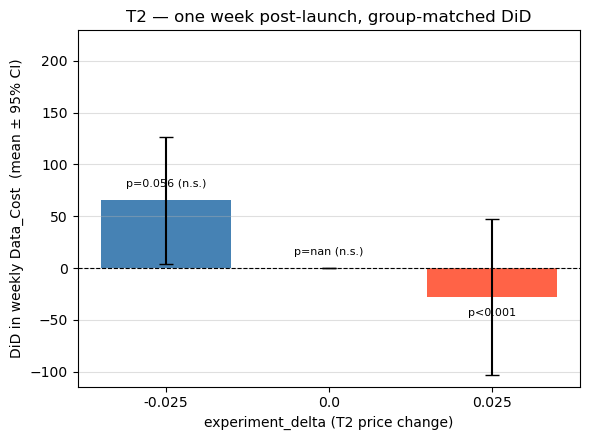

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.5))
plot_did_bars(ax, did_t2, 'did', metric='mean')
ax.set_xlabel('experiment_delta (T2 price change)')
ax.set_ylabel('DiD in weekly Data_Cost  (mean ± 95% CI)')
ax.set_title('T2 — one week post-launch, group-matched DiD')
plt.tight_layout()
plt.show()

In [10]:
print("T2 by revenue bucket:")
for b in BUCKET_ORDER:
    sub = did_t2[did_t2['bucket'] == b]
    if len(sub) == 0:
        continue
    print(f"\n--- bucket {b} (n={len(sub)}) ---")
    print(desc_stats(sub, 'did').to_string(index=False))

print("\nT2 by geo:")
for g in sorted(did_t2['geo'].dropna().unique()):
    sub = did_t2[did_t2['geo'] == g]
    if len(sub) == 0:
        continue
    print(f"\n--- geo {g} (n={len(sub)}) ---")
    print(desc_stats(sub, 'did').to_string(index=False))

T2 by revenue bucket:

--- bucket 0+ (n=154) ---
 delta  n t_pre t_post   mean  trim_mean   std  cdf0     p5    q25  median   q75   p95    p_t  p_trim  p_wilcox
-0.025 46     6      5  0.382      0.104 2.749 0.435 -0.861 -0.123   0.030 0.194 3.817 0.3566  0.1356    0.3044
 0.000 61     6      5  0.000      0.000 0.000 1.000  0.000  0.000   0.000 0.000 0.000    NaN     NaN    1.0000
 0.025 47     6      5 -1.379     -0.214 5.230 0.638 -7.162 -0.505  -0.033 0.051 1.034 0.0804  0.0053    0.0431

--- bucket 1+ (n=89) ---
 delta  n t_pre t_post   mean  trim_mean     std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
-0.025 25     6      5 44.007      0.358 218.241 0.480 -12.981 -1.566   0.173 2.034  8.925 0.3331  0.5308    0.6150
 0.000 36     6      5  0.000      0.000   0.000 1.000   0.000  0.000   0.000 0.000  0.000    NaN     NaN    1.0000
 0.025 28     6      5 38.426     -0.710 207.273 0.714 -18.807 -1.948  -0.594 0.516 25.528 0.3439  0.4032    0.1936

--- bucket 1


--- geo APAC (n=8) ---
 delta  n t_pre t_post    mean  trim_mean    std  cdf0      p5     q25  median     q75     p95    p_t  p_trim  p_wilcox
-0.025  3     6      5  15.241     15.241 16.087 0.333  -0.373   4.400  10.366  23.644  34.267 0.3122  0.3122       0.5
 0.000  4     6      5   0.000      0.000  0.000 1.000   0.000   0.000   0.000   0.000   0.000    NaN     NaN       1.0
 0.025  1     6      5 -45.748    -45.748  0.000 1.000 -45.748 -45.748 -45.748 -45.748 -45.748    NaN     NaN       1.0

--- geo Asia (n=96) ---
 delta  n t_pre t_post   mean  trim_mean   std  cdf0     p5    q25  median   q75   p95    p_t  p_trim  p_wilcox
-0.025 28     6      5  1.343      0.305 4.228 0.429 -0.509 -0.040   0.042 0.220 9.655 0.1106  0.1454    0.1709
 0.000 41     6      5  0.000      0.000 0.000 1.000  0.000  0.000   0.000 0.000 0.000    NaN     NaN    1.0000
 0.025 27     6      5 -0.172     -0.072 2.589 0.704 -1.701 -0.205  -0.039 0.009 0.976 0.7370  0.3451    0.1414

--- geo Global (n=115)

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:1087: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:1087: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


## Rollout — separating the Aug-17 cohort from the original May cohort

The 2,982 segments currently at `T1 -0.05` are not one homogeneous group — most only
just got there at the 8/17 round, but some have been there since the original May
experiment. The file's own `delta` column (this ROUND's price step vs the entering
price, not a cumulative offset) tells us exactly who moved *at 8/17 specifically*:

- **`delta != 0`** — the segment's price actually changed at the 2026-08-17 round. This
  is the real "Aug rollout" event — fresh entrants from `O`/`C1`, or segments switching
  out of the *other* T1 arm (`+0.05` → `-0.05`).
- **`delta == 0`** — the segment was already sitting at `-0.05` since the original May
  experiment and nothing happened to it this round. This is the "May cohort" — nothing
  new to measure here at 8/17; it's included below only as a sanity check (its `chg`
  should look flat).

This split also gives a simple control-cleanliness check: an `O`/`C1` row with
`delta == 0` this round was stable for the entire pre-window (confirmed flat all the
way back to 5/26 above), so no multi-snapshot lookback is needed for it either. The
~10 rows that got manually *restored* back to `O` at 8/17 (after having sat in a T1
arm) show up as `delta != 0` and are correctly excluded from control by this same
one-column check.

Note that `O` itself is tiny within `sharethis` (this whole notebook has already
dropped `dav2shreths`, which sat entirely in `O` for reasons unrelated to this test) —
control here is essentially `C1`, the deliberate T1 holdout.

Pre-period uses the full 6-week window (`test_df_start`, same as T2) — confirmed above
that nothing changed for anyone between 5/26 and 8/17, so there's no need to shorten
it. All three requested methods are run on the **Aug cohort**:

1. **Group-matched DiD** — same machinery as T1/T2, via `group`.
2. **Bucket-matched DiD** — control = every clean `O`/`C1` segment in the same revenue
   bucket, no group-match requirement.
3. **Pre/post trend only** — no control subtraction.

In [11]:
roll_all = assign[assign['state'].isin(['T1 -0.05', 'O', 'C1'])].copy()

aug_treated = roll_all[(roll_all['state'] == 'T1 -0.05') & (roll_all['delta'] != 0)].copy()
may_cohort  = roll_all[(roll_all['state'] == 'T1 -0.05') & (roll_all['delta'] == 0)].copy()
clean_ctrl  = roll_all[roll_all['state'].isin(['O', 'C1']) & (roll_all['delta'] == 0)].copy()
dirty_ctrl_n = (roll_all['state'].isin(['O', 'C1']) & (roll_all['delta'] != 0)).sum()

# Orphan-control fix: confirmed via full group composition that ~80 sharethis groups
# have a C1 member whose OTHER slot(s) went entirely to T2 (state pattern
# C1+C2+T2+-0.025), never to the rollout at all -- that C1 has zero rollout-treated
# counterpart in its own group and shouldn't count as this comparison's control.
_aug_groups = set(aug_treated['group'])
_orphan_ctrl_n = (~clean_ctrl['group'].isin(_aug_groups)).sum()
clean_ctrl = clean_ctrl[clean_ctrl['group'].isin(_aug_groups)].copy()

print(f"Aug cohort (newly at -0.05 this round): {len(aug_treated)}")
print(f"May cohort (already at -0.05 since the original May experiment, sanity-check only): {len(may_cohort)}")
print(f"Clean O/C1 control, in a group with a genuine rollout-treated member: {len(clean_ctrl)} "
      f"(dropped {_orphan_ctrl_n} orphaned -- their group's other slot(s) went to T2, not the rollout)")
print(f"Dropped {dirty_ctrl_n} O/C1 rows with delta!=0 this round (e.g. restored back from a T1 arm)")

roll_rows = pd.concat([aug_treated, clean_ctrl], ignore_index=True)
roll_rows['delta'] = np.where(roll_rows['state'] == 'T1 -0.05', -0.05, 0.0)
roll_rows = assign_bucket(roll_rows)

print("\nRollout (Aug cohort) pricing table:", len(roll_rows), "rows,", roll_rows['group'].nunique(), "groups")
print(roll_rows.groupby('state').size())

panel_roll = build_zero_filled_panel(dat, roll_rows)
_bucket_lookup_roll = reconcile_bucket_by_group(roll_rows)
_geo_lookup_roll = roll_rows.drop_duplicates('Full_Path').set_index('Full_Path')['geo']

Aug cohort (newly at -0.05 this round): 2709
May cohort (already at -0.05 since the original May experiment, sanity-check only): 273
Clean O/C1 control, in a group with a genuine rollout-treated member: 148 (dropped 84 orphaned -- their group's other slot(s) went to T2, not the rollout)
Dropped 10 O/C1 rows with delta!=0 this round (e.g. restored back from a T1 arm)

Rollout (Aug cohort) pricing table: 2857 rows, 1043 groups
state
C1           146
O              2
T1 -0.05    2709
dtype: int64


### Method 1: group-matched DiD

147/1043 treated groups (sharethis) retained an untouched control member
n=415 segments in the matched comparison

 delta   n t_pre t_post   mean  trim_mean    std  cdf0     p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 267     6      5 13.686      1.908 65.140 0.333 -7.905 -0.089   0.109 2.436 82.193 0.0007     0.0    0.0000
  0.00 148     6      5 -0.000      0.000  2.975 0.993  0.000  0.000   0.000 0.000  0.000 1.0000     NaN    0.6547


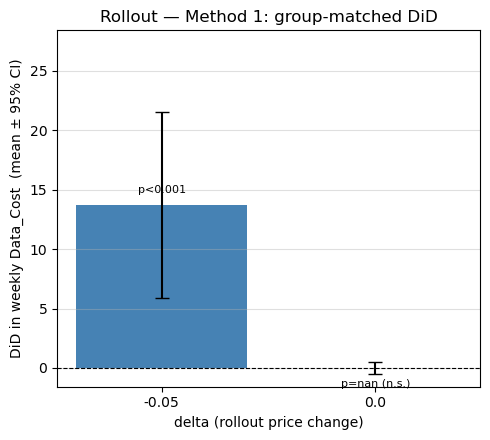


by revenue bucket:

--- bucket 0+ (n=228) ---
 delta   n t_pre t_post  mean  trim_mean    std  cdf0     p5    q25  median   q75   p95    p_t  p_trim  p_wilcox
 -0.05 148     6      5  2.35      0.107 17.143 0.365 -1.306 -0.074   0.022 0.231 6.081 0.0986   0.002    0.0069
  0.00  80     6      5  0.00      0.000  0.000 1.000  0.000  0.000   0.000 0.000 0.000    NaN     NaN    1.0000

--- bucket 1+ (n=91) ---
 delta  n t_pre t_post   mean  trim_mean   std  cdf0     p5    q25  median  q75     p95   p_t  p_trim  p_wilcox
 -0.05 59     6      5 16.789      2.036 60.54 0.305 -5.449 -0.124   0.489 2.49 137.855 0.039  0.0087    0.0034
  0.00 32     6      5  0.000      0.000  0.00 1.000  0.000  0.000   0.000 0.00   0.000   NaN     NaN    1.0000

--- bucket 10+ (n=75) ---
 delta  n t_pre t_post   mean  trim_mean     std  cdf0      p5   q25  median    q75    p95    p_t  p_trim  p_wilcox
 -0.05 48     6      5 34.929     18.059 107.734 0.229 -12.818 1.126   6.873 33.044 120.99 0.0311  0.0002    

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


In [12]:
did_roll_grp, test_roll, tm_grp = compute_did(panel_roll, test_df_start, match_col='group')
did_roll_grp['bucket'] = did_roll_grp['Full_Path'].map(_bucket_lookup_roll)
did_roll_grp['geo'] = did_roll_grp['Full_Path'].map(_geo_lookup_roll)

n_groups_total = roll_rows[roll_rows['delta'] != 0]['group'].nunique()
n_groups_matched = did_roll_grp[did_roll_grp['delta'] != 0]['group'].nunique()
print(f"{n_groups_matched}/{n_groups_total} treated groups (sharethis) retained an untouched control member")
print(f"n={len(did_roll_grp)} segments in the matched comparison\n")
print(desc_stats(did_roll_grp, 'did').to_string(index=False))

fig, ax = plt.subplots(figsize=(5, 4.5))
plot_did_bars(ax, did_roll_grp, 'did', metric='mean')
ax.set_xlabel('delta (rollout price change)')
ax.set_ylabel('DiD in weekly Data_Cost  (mean ± 95% CI)')
ax.set_title('Rollout — Method 1: group-matched DiD')
plt.tight_layout()
plt.show()

print("\nby revenue bucket:")
for b in BUCKET_ORDER:
    sub = did_roll_grp[did_roll_grp['bucket'] == b]
    if len(sub) == 0:
        continue
    print(f"\n--- bucket {b} (n={len(sub)}) ---")
    print(desc_stats(sub, 'did').to_string(index=False))

print("\nby geo:")
for g in sorted(did_roll_grp['geo'].dropna().unique()):
    sub = did_roll_grp[did_roll_grp['geo'] == g]
    if len(sub) == 0:
        continue
    print(f"\n--- geo {g} (n={len(sub)}) ---")
    print(desc_stats(sub, 'did').to_string(index=False))

### Method 2: bucket-matched DiD (no group-match requirement)

n=2857 segments (all sharethis rollout/O/C1 rows with pre+post data)

of these 2709 treated segments:
  267 also have a genuine group-level match (same segments as Method 1's 267)
  2442 rely ONLY on bucket-level pooling -- their own group was fully consumed, no individual revenue-neighbor control survives; read these as a looser comparison

distribution of treated:control ratio, per group (Aug cohort's own groups):


ratio
3:0 (no control)    645
2:0 (no control)    248
2:1                 120
1:1                  26
1:0 (no control)      2
1:2                   1
9:0 (no control)      1

 delta    n t_pre t_post   mean  trim_mean    std  cdf0     p5    q25  median    q75    p95   p_t  p_trim  p_wilcox
 -0.05 2709     6      5  4.461      0.010 91.217 0.754 -0.977 -0.236  -0.074 -0.007  9.026 0.011  0.2483    0.0000
  0.00  148     6      5 -0.000      0.151 16.660 0.649 -9.077 -0.318  -0.091  0.297 19.883 1.000  0.2132    0.1622


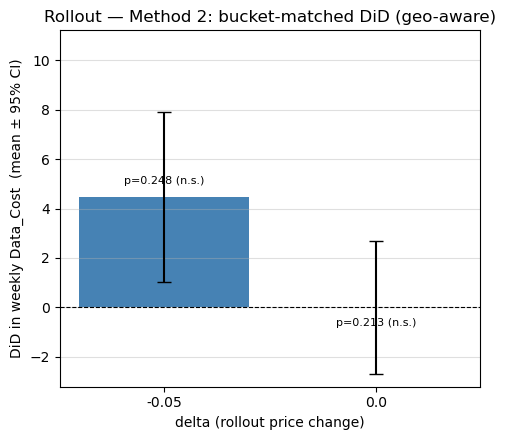


by revenue bucket:

--- bucket 0+ (n=2158) ---
 delta    n t_pre t_post  mean  trim_mean     std  cdf0     p5    q25  median    q75   p95    p_t  p_trim  p_wilcox
 -0.05 2078     6      5 2.665     -0.103 100.451 0.853 -0.295 -0.216  -0.074 -0.063 1.008 0.2268  0.0000    0.0000
  0.00   80     6      5 0.568     -0.068   3.968 0.750 -1.850 -0.191  -0.088  0.001 3.199 0.2072  0.0032    0.0042

--- bucket 1+ (n=392) ---
 delta   n t_pre t_post   mean  trim_mean    std  cdf0     p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 360     6      5  1.848      0.462  8.688 0.506 -3.006 -0.268  -0.010 1.192 11.190 0.0001  0.0000    0.0044
  0.00  32     6      5 -3.130     -0.239 17.548 0.656 -6.134 -0.792  -0.252 0.127  4.748 0.3283  0.2079    0.1641

--- bucket 10+ (n=258) ---
 delta   n t_pre t_post   mean  trim_mean    std  cdf0      p5    q25  median    q75    p95    p_t  p_trim  p_wilcox
 -0.05 231     6      5 14.151      5.955 60.376 0.342 -11.176 -0.502   2.542 10.953 57

In [13]:
# match_col='bucket_geo' -- pools control within the SAME (geo, bucket) cell, not just
# bucket alone (same reasoning as `group`'s geo-fix: the original design is scoped per
# provider x geo, so pooling control across geos within a bucket repeats that mistake).
did_roll_bkt, _, _ = compute_did(panel_roll, test_df_start, match_col='bucket_geo')
did_roll_bkt['bucket'] = did_roll_bkt['Full_Path'].map(_bucket_lookup_roll)
did_roll_bkt['geo'] = did_roll_bkt['Full_Path'].map(_geo_lookup_roll)
print(f"n={len(did_roll_bkt)} segments (all sharethis rollout/O/C1 rows with pre+post data)\n")

# "n" here is NOT 2,709 individually-matched pairs -- most of this population's own
# group was fully consumed by the rollout (every group-mate also treated, or a
# May-cohort member with no control left), so their "control" is only some other
# segment in the same broad bucket, not a close revenue-neighbor. Splitting out how
# many of these treated segments still have a genuine group-level match (Method 1's
# own 267) vs. how many rely purely on bucket-level pooling, so that distinction is
# visible every time this is re-run, not just reasoned through once.
_tight_matched_paths = set(did_roll_grp[did_roll_grp['delta'] != 0]['Full_Path'])
_bkt_treated = did_roll_bkt[did_roll_bkt['delta'] != 0]
_n_tight = _bkt_treated['Full_Path'].isin(_tight_matched_paths).sum()
_n_loose = len(_bkt_treated) - _n_tight
print(f"of these {len(_bkt_treated)} treated segments:")
print(f"  {_n_tight} also have a genuine group-level match (same segments as Method 1's {len(_tight_matched_paths)})")
print(f"  {_n_loose} rely ONLY on bucket-level pooling -- their own group was fully consumed, "
      f"no individual revenue-neighbor control survives; read these as a looser comparison\n")

# Distribution of treated:control ratio per group, across the Aug cohort's own
# groups (roll_rows already carries the geo-qualified 'group' key) -- shows exactly
# how the 267/2709 split above arises: groups are size-3, so 2:1 and 1:1 are the only
# possible ratios with a surviving control; anything else (3:0, 2:0 May-only, etc.)
# has none at all.
_grp_counts = roll_rows.groupby('group')['delta'].apply(lambda d: pd.Series({
    'n_treated': (d != 0).sum(), 'n_control': (d == 0).sum()
})).unstack()
_grp_counts['ratio'] = _grp_counts.apply(
    lambda r: f"{int(r.n_treated)}:{int(r.n_control)}" if r.n_control > 0 else f"{int(r.n_treated)}:0 (no control)",
    axis=1
)
print("distribution of treated:control ratio, per group (Aug cohort's own groups):")
print(_grp_counts['ratio'].value_counts().to_string())
print()

print(desc_stats(did_roll_bkt, 'did').to_string(index=False))

fig, ax = plt.subplots(figsize=(5, 4.5))
plot_did_bars(ax, did_roll_bkt, 'did', metric='mean')
ax.set_xlabel('delta (rollout price change)')
ax.set_ylabel('DiD in weekly Data_Cost  (mean ± 95% CI)')
ax.set_title('Rollout — Method 2: bucket-matched DiD (geo-aware)')
plt.tight_layout()
plt.show()

# control_chg_mean is now computed per (geo, bucket) cell -- each such cell's own
# control did still cancels to exactly 0 by construction; slicing the result by plain
# bucket (pooling multiple geos' cells together afterward) no longer breaks that,
# since averaging several already-zero-mean groups together is still zero.
print("\nby revenue bucket:")
for b in BUCKET_ORDER:
    sub = did_roll_bkt[did_roll_bkt['bucket'] == b]
    if len(sub) == 0:
        continue
    print(f"\n--- bucket {b} (n={len(sub)}) ---")
    print(desc_stats(sub, 'did').to_string(index=False))

print("\nby geo:")
for g in sorted(did_roll_bkt['geo'].dropna().unique()):
    sub = did_roll_bkt[did_roll_bkt['geo'] == g]
    if len(sub) == 0:
        continue
    print(f"\n--- geo {g} (n={len(sub)}) ---")
    print(desc_stats(sub, 'did').to_string(index=False))

### Method 2 results — full (geo x bucket) cross-tabulation

The by-bucket and by-geo breakdowns above each pool across the other dimension. Here
both are held fixed at once, using the same `did_roll_bkt` (already matched at the
(geo, bucket) cell level, so each cell's own control `did` still cancels to ~0 by
construction).

In [14]:
print("Rollout Method 2 -- full (geo x bucket) cross-tabulation:")
for g in sorted(did_roll_bkt['geo'].dropna().unique()):
    for b in BUCKET_ORDER:
        sub = did_roll_bkt[(did_roll_bkt['geo'] == g) & (did_roll_bkt['bucket'] == b)]
        if len(sub) == 0:
            continue
        print(f"\n--- geo={g}, bucket={b} (n={len(sub)}) ---")
        print(desc_stats(sub, 'did').to_string(index=False))

Rollout Method 2 -- full (geo x bucket) cross-tabulation:

--- geo=Asia, bucket=0+ (n=1014) ---
 delta   n t_pre t_post   mean  trim_mean   std  cdf0     p5    q25  median    q75   p95    p_t  p_trim  p_wilcox
 -0.05 976     6      5 -0.007     -0.071 0.492 0.898 -0.155 -0.076  -0.074 -0.067 0.181 0.6526  0.0000    0.0000
  0.00  38     6      5  0.180     -0.038 1.024 0.763 -0.194 -0.100  -0.078 -0.013 0.824 0.2928  0.1247    0.1184

--- geo=Asia, bucket=1+ (n=69) ---
 delta  n t_pre t_post  mean  trim_mean   std  cdf0     p5    q25  median   q75   p95    p_t  p_trim  p_wilcox
 -0.05 64     6      5 0.512      0.319 1.541 0.422 -0.956 -0.075   0.063 0.354 3.713 0.0106  0.0014    0.0131
  0.00  5     6      5 0.233      0.233 1.083 0.400 -1.012 -0.102   0.034 0.362 1.761 0.6890  0.6890    0.8125

--- geo=Asia, bucket=10+ (n=12) ---
 delta  n t_pre t_post   mean  trim_mean    std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05  8     6      5  2.968      2.968 

 delta   n t_pre t_post   mean  trim_mean    std  cdf0     p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 125     6      5  2.770      0.702 12.442 0.504 -1.019 -0.254  -0.018 1.556 11.503 0.0145  0.0000    0.0149
  0.00   6     6      5 -0.911     -0.911  4.182 0.667 -7.298 -1.041  -0.347 0.965  3.655 0.6468  0.6468    0.8438

--- geo=Global, bucket=10+ (n=115) ---
 delta   n t_pre t_post  mean  trim_mean    std  cdf0     p5    q25  median    q75    p95    p_t  p_trim  p_wilcox
 -0.05 110     6      5 7.867      3.743 19.642   0.4 -8.039 -0.399   1.734  6.896 45.490 0.0001  0.0000    0.0000
  0.00   5     6      5 7.208      7.208  9.017   0.4 -0.889 -0.149   2.218 12.716 20.405 0.1851  0.1851    0.3125

--- geo=Global, bucket=100+ (n=22) ---
 delta  n t_pre t_post    mean  trim_mean     std  cdf0      p5     q25  median     q75     p95    p_t  p_trim  p_wilcox
 -0.05 19     6      5  89.127     70.833 138.055 0.263  -5.071  -0.038  32.635 115.272 370.180 0.0135  0.012

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:1087: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:1087: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


### Method 2 revenue impact — geo x bucket matrix

Same `did_roll_bkt` treated rows as the cross-tabulation above, but as a compact
weekly-$-impact matrix instead of a stack of per-cell stat blocks. Two views, since raw
sums are outlier-sensitive (see the ATE section's note on this) -- **sum** is the
literal total (what `dollar_summary` uses elsewhere in this notebook), **trimmed** is
`trim_mean x n`, a more robust view of the "typical" per-cell contribution.

In [15]:
_treated_m2 = did_roll_bkt[did_roll_bkt['delta'] != 0]

def _trim_sum(v):
    n = len(v)
    return float(__trim_mean(v, 0.1)) * n if n >= 3 else float(v.sum())

_grp = _treated_m2.groupby(['geo', 'bucket'])['did']
cell_impact = _grp.agg(n='size', sum_impact='sum')
cell_impact['trim_impact'] = _grp.apply(_trim_sum)

def _to_matrix(col, fill=0.0):
    m = cell_impact[col].unstack('bucket').reindex(columns=BUCKET_ORDER).fillna(fill)
    m['Total'] = m.sum(axis=1)
    m.loc['Total'] = m.sum(axis=0)
    return m

mat_n = _to_matrix('n')
mat_sum = _to_matrix('sum_impact')
mat_trim = _to_matrix('trim_impact')

def _styled_matrix(value_df, n_df, fmt, caption, cmap='RdYlGn', vmax=None):
    """Displays value_df's numbers with each cell's own n folded into the label
    (e.g. '$425 (n=327)') -- color (gmap) still keys off the raw numeric value_df,
    not the text, via Styler's gmap param, so the annotated text doesn't break the
    heatmap coloring. `vmax` can be overridden so one extreme/unstable cell (e.g. the
    0+ bucket's percentage estimate) doesn't wash out the color scale for every
    other, well-behaved cell."""
    labels = value_df.copy().astype(object)
    for r in value_df.index:
        for c in value_df.columns:
            v, n = value_df.loc[r, c], n_df.loc[r, c]
            labels.loc[r, c] = f"{fmt(v)} (n={int(n)})"
    if vmax is None:
        vmax = value_df.abs().to_numpy().max()
    return (
        labels.style
        .background_gradient(cmap=cmap, axis=None, gmap=value_df.clip(-vmax, vmax).to_numpy(), vmin=-vmax, vmax=vmax)
        .set_caption(caption)
    )

display(_styled_matrix(mat_sum, mat_n, lambda v: f"${v:,.0f}", "Weekly $ impact -- raw sum (outlier-sensitive), n = treated segments"))
display(_styled_matrix(mat_trim, mat_n, lambda v: f"${v:,.0f}", "Weekly $ impact -- trim_mean x n (robust), n = treated segments"))

bucket,0+,1+,10+,100+,1000+,Total
geo,,,,,,
Asia,$-7 (n=976),$33 (n=64),$24 (n=8),$0 (n=0),$0 (n=0),$50 (n=1048)
Global,$425 (n=327),$346 (n=125),$865 (n=110),"$1,693 (n=19)",$0 (n=0),"$3,330 (n=581)"
US,$119 (n=465),$262 (n=109),"$2,233 (n=82)",$559 (n=19),$0 (n=0),"$3,174 (n=675)"
Unknown,"$5,000 (n=310)",$24 (n=62),$147 (n=31),$360 (n=2),$0 (n=0),"$5,531 (n=405)"
Total,"$5,538 (n=2078)",$665 (n=360),"$3,269 (n=231)","$2,613 (n=40)",$0 (n=0),"$12,085 (n=2709)"


bucket,0+,1+,10+,100+,1000+,Total
geo,,,,,,
Asia,$-69 (n=976),$20 (n=64),$24 (n=8),$0 (n=0),$0 (n=0),$-25 (n=1048)
Global,$-53 (n=327),$88 (n=125),$412 (n=110),"$1,346 (n=19)",$0 (n=0),"$1,792 (n=581)"
US,$-20 (n=465),$93 (n=109),"$1,060 (n=82)",$639 (n=19),$0 (n=0),"$1,772 (n=675)"
Unknown,$-73 (n=310),$-59 (n=62),$15 (n=31),$360 (n=2),$0 (n=0),$243 (n=405)
Total,$-216 (n=2078),$142 (n=360),"$1,511 (n=231)","$2,345 (n=40)",$0 (n=0),"$3,782 (n=2709)"


### Cluster-level significance (Method 2) -- fixing the pseudo-replication problem

`did_roll_bkt`'s p-values above treat each of the 2,709 segments as an independent
observation, but `control_chg_mean` is estimated once per (geo, bucket) cell and reused
across every segment in it -- up to 976 in a single cell. That's pseudo-replication:
noise in one shared control estimate gets counted as hundreds of "independent"
data points, artificially shrinking the p-values.

**Fix**: collapse to one diff per cell (`treated_mean_chg - control_mean_chg`) and run
the test across the ~15-20 cells instead of the ~2,709 segments -- two versions:
- **Unweighted**: one-sample t-test / Wilcoxon on the cell-level diffs, every cell
  counted once regardless of how many segments built it.
- **Weighted (inverse-variance meta-analysis)**: weight each cell's diff by
  `1/SE_i^2` (its own within-cell two-sample standard error), so a precisely-estimated
  cell (many segments, low variance) counts for more -- the standard tool for
  combining several independent effect estimates into one pooled estimate + p-value.

Since we already know the buckets differ systematically (0+ looks flat, 1+/10+/100+
look positive), pooling ALL cells into one grand p-value would average a real zero
and a real positive together and call it "the effect" -- not meaningful. A Cochran's Q
heterogeneity check below confirms this, so the pooled test is run **per bucket**
(across geos only) rather than as one number across every cell.

In [16]:
def _cell_stats(df):
    """One row's worth of cluster-level inputs for a single (geo,bucket) cell:
    treated/control mean chg, the diff, its two-sample SE, and each side's own
    pre-period baseline level (needed to convert the dollar diff into a %-of-baseline
    effect below -- this SE calculation is completely standard -- unequal n handled
    the normal way -- it's only the SECOND stage, across cells, where the small-n
    problem shows up)."""
    t = df[df['delta'] != 0]
    c = df[df['delta'] == 0]
    if len(t) < 2 or len(c) < 2:
        return None
    diff = t['chg'].mean() - c['chg'].mean()
    se = np.sqrt(t['chg'].var(ddof=1) / len(t) + c['chg'].var(ddof=1) / len(c))
    return pd.Series({
        'n_treated': len(t), 'n_control': len(c), 'diff': diff, 'se': se,
        'baseline_control': c['Data_Cost_pre'].mean(), 'baseline_treated': t['Data_Cost_pre'].mean(),
    })

cell_level = did_roll_bkt.groupby(['geo', 'bucket']).apply(_cell_stats, include_groups=False).dropna().reset_index()
print(f"n cells with both treated and control (>=2 each): {len(cell_level)}")
print(cell_level.to_string(index=False))

n cells with both treated and control (>=2 each): 14
    geo bucket  n_treated  n_control       diff        se  baseline_control  baseline_treated
   Asia     0+      976.0       38.0   0.985821  1.069529          2.037939          0.122888
   Asia     1+       64.0        5.0   1.701657  0.788312          2.112000          1.049661
   Asia    10+        8.0        4.0   7.047667  8.575131         18.118333          4.780417
 Global     0+      327.0       15.0   0.563520  1.130830         15.286222          1.590601
 Global     1+      125.0        6.0   3.704425  2.238483          6.843889          3.255933
 Global    10+      110.0        5.0   6.342488  2.431188         13.722667          7.961197
 Global   100+       19.0        3.0 105.477690 40.595156         50.801111         59.266053
     US     0+      465.0       15.0   0.738467  0.427264          0.595111          0.275487
     US     1+      109.0       14.0   1.771914  0.718187          1.174167          2.241391
     US

In [17]:
# Cochran's Q -- tests whether the cells' diffs are consistent with ONE shared true
# effect (small Q relative to df) or whether they genuinely differ (large Q) -- if
# they differ, a single pooled p-value across ALL cells isn't a meaningful summary.
def cochrans_q(diffs, ses):
    w = 1 / ses**2
    pooled = (w * diffs).sum() / w.sum()
    Q = (w * (diffs - pooled)**2).sum()
    df = len(diffs) - 1
    p_het = 1 - stats.chi2.cdf(Q, df)
    return Q, df, p_het

Q, df_q, p_het = cochrans_q(cell_level['diff'].values, cell_level['se'].values)
print(f"Cochran's Q = {Q:.1f} on df={df_q}, p={p_het:.4f}")
print("-> " + ("cells do NOT share one common effect (heterogeneous) -- pool per bucket, not across all cells"
                if p_het < 0.05 else
                "no strong evidence against one shared effect -- pooling across all cells is defensible"))

Cochran's Q = 28.0 on df=13, p=0.0092
-> cells do NOT share one common effect (heterogeneous) -- pool per bucket, not across all cells


In [18]:
from scipy.stats import norm as _norm

def unweighted_test(diffs):
    _, p_t = stats.ttest_1samp(diffs, popmean=0)
    p_w = wilcoxon_safe(diffs) if len(diffs) >= 2 else np.nan
    return p_t, p_w

def weighted_meta(diffs, ses):
    """Fixed-effect inverse-variance meta-analysis: pooled_effect is the
    precision-weighted average of the per-cell diffs, pooled_SE shrinks as more/
    more-precise cells are added -- z = pooled_effect / pooled_SE, two-sided normal p."""
    w = 1 / ses**2
    pooled_effect = (w * diffs).sum() / w.sum()
    pooled_se = np.sqrt(1 / w.sum())
    z = pooled_effect / pooled_se
    p = 2 * (1 - _norm.cdf(abs(z)))
    return pooled_effect, pooled_se, p

print("=== Across ALL cells pooled (for reference only -- Q above says buckets differ) ===")
p_t_all, p_w_all = unweighted_test(cell_level['diff'].values)
pe_all, pse_all, p_meta_all = weighted_meta(cell_level['diff'].values, cell_level['se'].values)
print(f"unweighted: n={len(cell_level)} cells, mean diff={cell_level['diff'].mean():.3f}, p_t={p_t_all:.4f}, p_wilcox={p_w_all:.4f}")
print(f"weighted (meta): pooled effect={pe_all:.3f}, pooled SE={pse_all:.3f}, p={p_meta_all:.4f}")

print("\n=== Per bucket (across geos) -- the meaningful version given the heterogeneity above ===")
rows = []
for b in BUCKET_ORDER:
    sub = cell_level[cell_level['bucket'] == b]
    if len(sub) < 2:
        continue
    p_t, p_w = unweighted_test(sub['diff'].values)
    pe, pse, p_meta = weighted_meta(sub['diff'].values, sub['se'].values)
    rows.append({
        'bucket': b, 'n_cells': len(sub), 'n_treated_total': int(sub['n_treated'].sum()),
        'unweighted_mean_diff': round(sub['diff'].mean(), 3), 'p_t': round(p_t, 4), 'p_wilcox': round(p_w, 4),
        'weighted_pooled_diff': round(pe, 3), 'weighted_pooled_se': round(pse, 3), 'p_meta': round(p_meta, 4),
    })
print(pd.DataFrame(rows).to_string(index=False))

=== Across ALL cells pooled (for reference only -- Q above says buckets differ) ===
unweighted: n=14 cells, mean diff=20.370, p_t=0.0252, p_wilcox=0.0001
weighted (meta): pooled effect=1.262, pooled SE=0.300, p=0.0000

=== Per bucket (across geos) -- the meaningful version given the heterogeneity above ===
bucket  n_cells  n_treated_total  unweighted_mean_diff    p_t  p_wilcox  weighted_pooled_diff  weighted_pooled_se  p_meta
    0+        4             2078                 4.996 0.3231     0.125                 0.760               0.374  0.0422
    1+        4              360                17.542 0.3309     0.125                 1.853               0.517  0.0003
   10+        4              231                17.376 0.0894     0.125                 7.549               2.273  0.0009
  100+        2               38                62.761 0.3805     0.500                30.602              14.271  0.0320


### Does the PERCENTAGE effect agree across buckets? (the treatment itself is identical)

The dollar-diff heterogeneity above is almost mechanical: a 0+ segment's baseline is
~$0.003/week and a 1000+ segment's is ~$400/week, so absolute dollar effects *must*
differ by orders of magnitude even if the underlying price response is identical --
that's not evidence the treatment worked differently by bucket, it's just baseline
scale. Since every segment got the exact same -5% price cut, the more meaningful
question is whether the **percentage** effect (dollar diff / baseline revenue) is
consistent across buckets -- if it is, that's strong support for "one treatment, one
underlying response," reported at whatever bucket-specific dollar scale you like.

`pct_diff = diff / baseline_control x 100`, with SE rescaled the same way (baseline is
treated as fixed/known, standard for this kind of ratio). **Caveat**: the 0+ bucket's
control baseline is only ~$0.003-0.005/week -- dividing by a number that close to zero
makes any %-based estimate extremely unstable there, so treat 0+'s percentage numbers
as close to undefined, not as a genuine "no effect" reading.

In [19]:
cell_level['pct_diff'] = cell_level['diff'] / cell_level['baseline_control'] * 100
cell_level['pct_se'] = cell_level['se'] / cell_level['baseline_control'].abs() * 100
print(cell_level[['geo', 'bucket', 'n_treated', 'baseline_control', 'diff', 'pct_diff', 'pct_se']].to_string(index=False))

Q_pct, df_q_pct, p_het_pct = cochrans_q(cell_level['pct_diff'].values, cell_level['pct_se'].values)
print(f"\nCochran's Q (percentage scale) = {Q_pct:.1f} on df={df_q_pct}, p={p_het_pct:.4f}")
print("-> " + ("cells still do NOT share one common % effect"
                if p_het_pct < 0.05 else
                "no strong evidence against ONE shared % effect across buckets -- consistent with a single underlying treatment response"))

# Same check excluding 0+ (baseline too close to zero for a stable % estimate)
_ex0 = cell_level[cell_level['bucket'] != ZERO_BUCKET_LABEL]
Q_ex0, df_ex0, p_ex0 = cochrans_q(_ex0['pct_diff'].values, _ex0['pct_se'].values)
print(f"\nSame check, excluding 0+ bucket: Q = {Q_ex0:.1f} on df={df_ex0}, p={p_ex0:.4f}")

print("\n=== Pooled % effect across ALL cells (unweighted + weighted) ===")
p_t_pct, p_w_pct = unweighted_test(cell_level['pct_diff'].values)
pe_pct, pse_pct, p_meta_pct = weighted_meta(cell_level['pct_diff'].values, cell_level['pct_se'].values)
print(f"unweighted: mean %diff={cell_level['pct_diff'].mean():.1f}%, p_t={p_t_pct:.4f}, p_wilcox={p_w_pct:.4f}")
print(f"weighted (meta): pooled %diff={pe_pct:.1f}%, pooled SE={pse_pct:.1f}pp, p={p_meta_pct:.4f}")

print("\n=== Pooled % effect, excluding 0+ ===")
p_t_ex0, p_w_ex0 = unweighted_test(_ex0['pct_diff'].values)
pe_ex0, pse_ex0, p_meta_ex0 = weighted_meta(_ex0['pct_diff'].values, _ex0['pct_se'].values)
print(f"unweighted: mean %diff={_ex0['pct_diff'].mean():.1f}%, p_t={p_t_ex0:.4f}, p_wilcox={p_w_ex0:.4f}")
print(f"weighted (meta): pooled %diff={pe_ex0:.1f}%, pooled SE={pse_ex0:.1f}pp, p={p_meta_ex0:.4f}")

    geo bucket  n_treated  baseline_control       diff   pct_diff     pct_se
   Asia     0+      976.0          2.037939   0.985821  48.373425  52.480899
   Asia     1+       64.0          2.112000   1.701657  80.570894  37.325395
   Asia    10+        8.0         18.118333   7.047667  38.897985  47.328477
 Global     0+      327.0         15.286222   0.563520   3.686460   7.397707
 Global     1+      125.0          6.843889   3.704425  54.127484  32.707756
 Global    10+      110.0         13.722667   6.342488  46.219062  17.716587
 Global   100+       19.0         50.801111 105.477690 207.628707  79.909977
     US     0+      465.0          0.595111   0.738467 124.088872  71.795625
     US     1+      109.0          1.174167   1.771914 150.908232  61.165707
     US    10+       82.0         34.841667  36.225357 103.971367  41.361678
     US   100+       19.0         56.398000  20.043635  35.539620  27.028960
Unknown     0+      310.0          2.896528  17.697386 610.986229 510.545764

unweighted: mean %diff=88.6%, p_t=0.0006, p_wilcox=0.0020
weighted (meta): pooled %diff=61.2%, pooled SE=11.0pp, p=0.0000


In [20]:
def _pct_to_matrix(col, fill=np.nan):
    m = cell_level.set_index(['geo', 'bucket'])[col].unstack('bucket').reindex(columns=BUCKET_ORDER).fillna(fill)
    return m

mat_pct = _pct_to_matrix('pct_diff')
mat_n_pct = _pct_to_matrix('n_treated', fill=0)

# Cap the color scale using only the non-0+ cells -- 0+'s percentage estimates are
# unstable (near-zero baseline denominator, see note above) and would otherwise wash
# out the color scale for every other, well-behaved cell. The raw number is still
# shown in the label for 0+, just not driving the color range.
_vmax_pct = mat_pct.drop(columns=[ZERO_BUCKET_LABEL], errors='ignore').abs().to_numpy()
_vmax_pct = np.nanmax(_vmax_pct) if np.isfinite(_vmax_pct).any() else mat_pct.abs().to_numpy().max()

display(
    _styled_matrix(mat_pct.fillna(0), mat_n_pct, lambda v: f"{v:+.0f}%",
                   "Percentage impact by geo x bucket, n = treated segments (0+ shown but unstable -- see note above)",
                   vmax=_vmax_pct)
)

bucket,0+,1+,10+,100+,1000+
geo,,,,,
Asia,+48% (n=976),+81% (n=64),+39% (n=8),+0% (n=0),+0% (n=0)
Global,+4% (n=327),+54% (n=125),+46% (n=110),+208% (n=19),+0% (n=0)
US,+124% (n=465),+151% (n=109),+104% (n=82),+36% (n=19),+0% (n=0)
Unknown,+611% (n=310),+81% (n=62),+87% (n=31),+0% (n=0),+0% (n=0)


In [21]:
# Diagnostic: does every (geo, bucket) cell with a treated segment also have a
# control segment? compute_did silently drops any row whose match_col value has
# NO delta==0 members at all (dropna(subset=['control_chg_mean'])) -- checking
# whether that's actually happening here, and for how many segments.
_roll_treated_all = roll_rows[roll_rows['delta'] != 0]
_roll_ctrl_all = roll_rows[roll_rows['delta'] == 0]
_cells_treated = set(_roll_treated_all['bucket_geo'])
_cells_ctrl = set(_roll_ctrl_all['bucket_geo'])
_cells_no_ctrl = _cells_treated - _cells_ctrl
print(f"(geo,bucket) cells with a treated segment: {len(_cells_treated)}")
print(f"(geo,bucket) cells with treated but NO control at all: {len(_cells_no_ctrl)}")
if _cells_no_ctrl:
    _dropped = _roll_treated_all[_roll_treated_all['bucket_geo'].isin(_cells_no_ctrl)]
    print(f"cells: {sorted(_cells_no_ctrl)}")
    print(f"treated segments in those cells (dropped from did_roll_bkt by compute_did): {len(_dropped)}")
print(f"\nroll_rows treated total: {len(_roll_treated_all)} | did_roll_bkt treated total: {(did_roll_bkt['delta'] != 0).sum()}")

(geo,bucket) cells with a treated segment: 16
(geo,bucket) cells with treated but NO control at all: 0

roll_rows treated total: 2709 | did_roll_bkt treated total: 2709


### Method 3: pre/post trend only (no control)

In [22]:
# Reuses tm_grp (Method 1's pre-control-subtraction pre/post table, already
# computed above) rather than rebuilding it -- same test/filter logic, same t_pre/t_post.
treated_only = tm_grp[tm_grp['delta'] != 0].copy()
treated_only['bucket'] = treated_only['Full_Path'].map(_bucket_lookup_roll)
treated_only['geo'] = treated_only['Full_Path'].map(_geo_lookup_roll)

print(f"n={len(treated_only)} rolled-out segments, own pre/post change, no control subtracted\n")
print(desc_stats(treated_only, 'chg').to_string(index=False))

print("\nby revenue bucket:")
for b in BUCKET_ORDER:
    sub = treated_only[treated_only['bucket'] == b]
    if len(sub) == 0:
        continue
    print(f"\n--- bucket {b} (n={len(sub)}) ---")
    print(desc_stats(sub, 'chg').to_string(index=False))

print("\nby geo:")
for g in sorted(treated_only['geo'].dropna().unique()):
    sub = treated_only[treated_only['geo'] == g]
    if len(sub) == 0:
        continue
    print(f"\n--- geo {g} (n={len(sub)}) ---")
    print(desc_stats(sub, 'chg').to_string(index=False))

n=2709 rolled-out segments, own pre/post change, no control subtracted

 delta    n t_pre t_post  mean  trim_mean    std  cdf0     p5    q25  median  q75   p95    p_t  p_trim  p_wilcox
 -0.05 2709     6      5 3.784      0.067 90.858 0.602 -1.022 -0.007     0.0 0.04 7.323 0.0303     0.0       0.0

by revenue bucket:

--- bucket 0+ (n=2078) ---
 delta    n t_pre t_post  mean  trim_mean     std  cdf0     p5    q25  median   q75   p95    p_t  p_trim  p_wilcox
 -0.05 2078     6      5 2.689      0.009 100.482 0.641 -0.186 -0.002     0.0 0.013 0.871 0.2228     0.0       0.0

--- bucket 1+ (n=360) ---
 delta   n t_pre t_post  mean  trim_mean   std  cdf0     p5    q25  median   q75  p95    p_t  p_trim  p_wilcox
 -0.05 360     6      5 1.559      0.321 7.676 0.528 -1.492 -0.271     0.0 0.865  8.6 0.0001     0.0    0.0163

--- bucket 10+ (n=231) ---
 delta   n t_pre t_post   mean  trim_mean    std  cdf0      p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 231     6      5 10.561 


--- geo US (n=675) ---
 delta   n t_pre t_post  mean  trim_mean    std  cdf0    p5    q25  median   q75    p95    p_t  p_trim  p_wilcox
 -0.05 675     6      5 3.043      0.196 35.802 0.523 -1.31 -0.012     0.0 0.149 19.186 0.0277     0.0       0.0

--- geo Unknown (n=405) ---
 delta   n t_pre t_post   mean  trim_mean     std  cdf0     p5    q25  median   q75   p95   p_t  p_trim  p_wilcox
 -0.05 405     6      5 13.339      0.195 226.856 0.612 -1.557 -0.002     0.0 0.094 8.756 0.238     0.0       0.0


## Time series — weekly revenue, before vs. after

Weekly mean `Data_Cost` per segment, treated vs. control, faceted two ways: by revenue
bucket (aggregating across geo) and by geo (aggregating across bucket). The dashed
vertical line marks the boundary between the pre-period and the first post-period
week (8/17). Same zero-filled panels used throughout this notebook, so a $0 week is a
real "no matched IDs that week," not a gap.

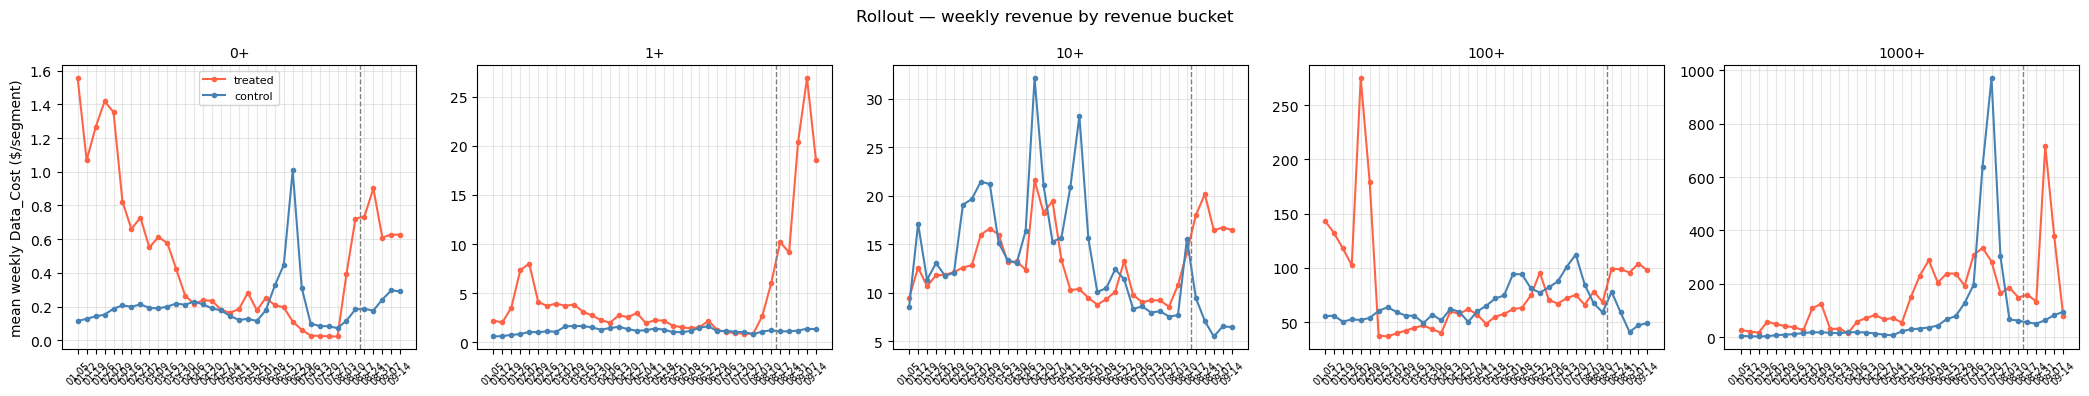

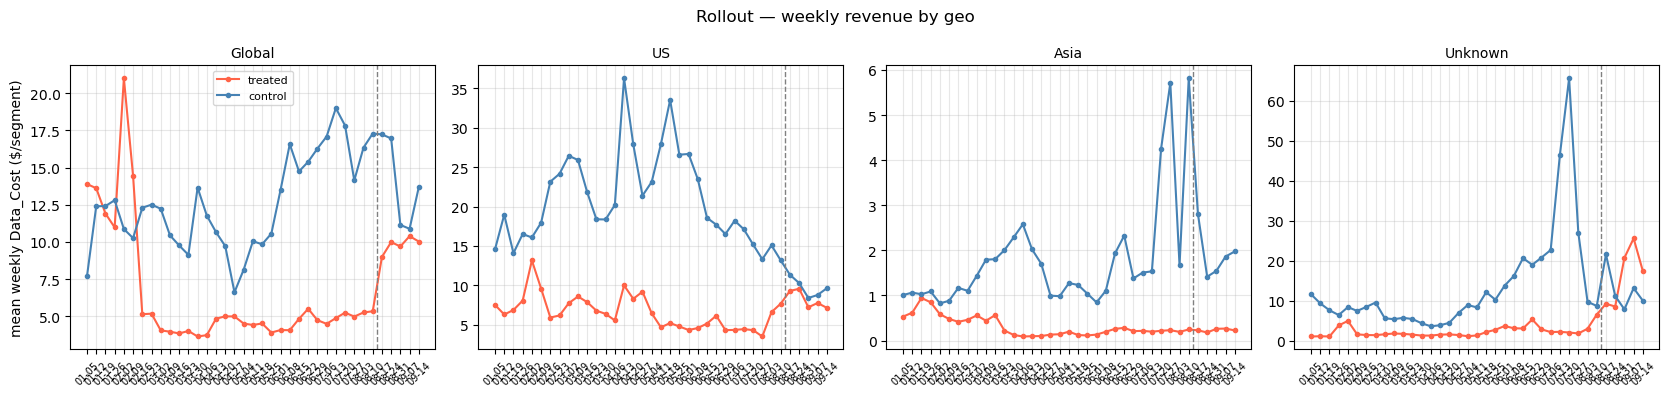

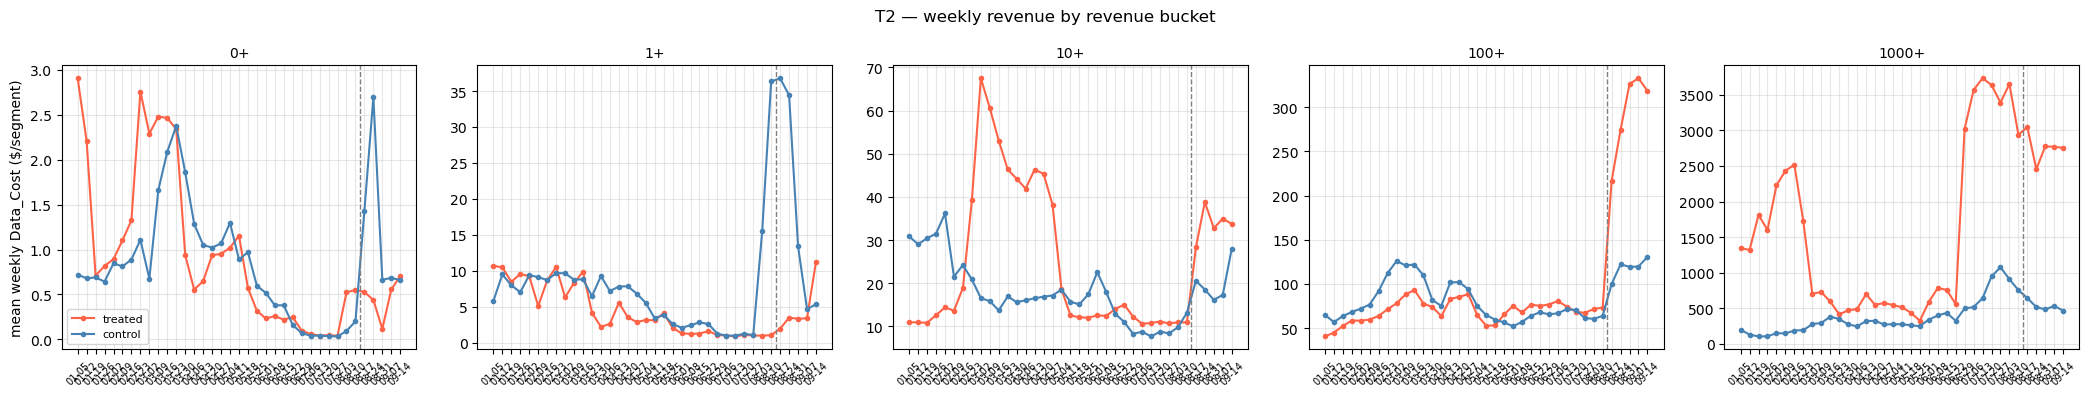

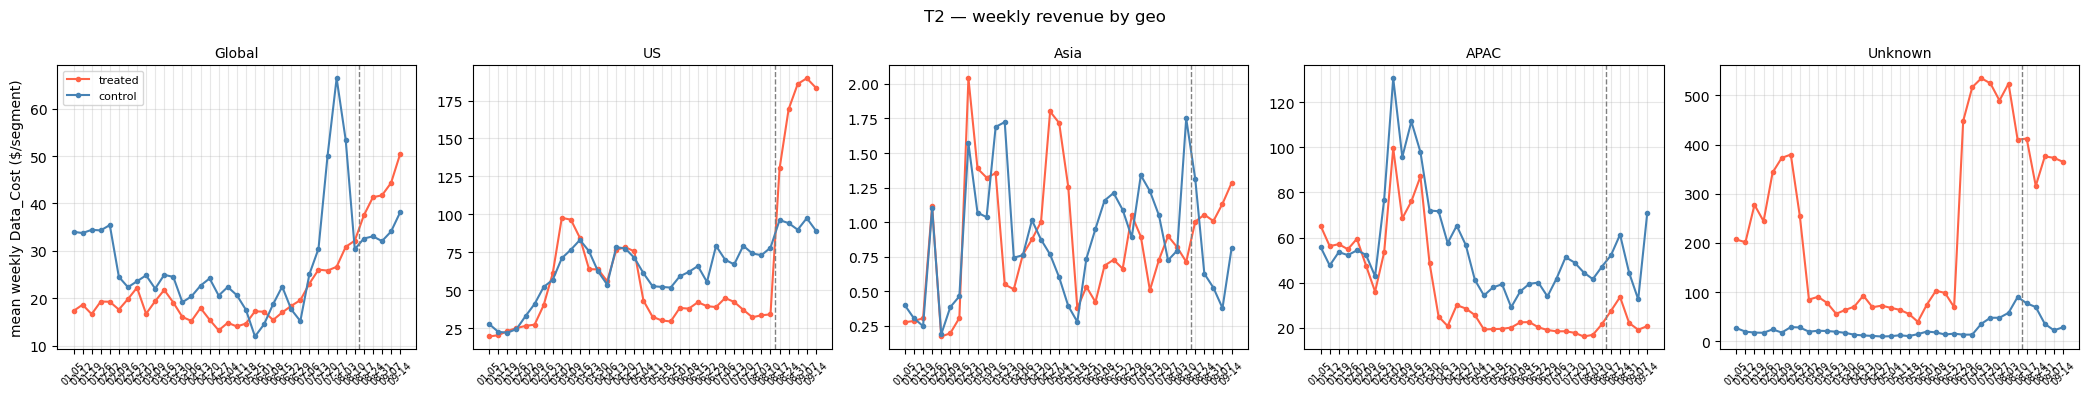

In [23]:
def plot_weekly_by(panel, facet_col, facet_order, title):
    """One small-multiple panel per facet_col value: weekly mean Data_Cost,
    treated (delta != 0) vs control (delta == 0), zero-filled panel already
    guarantees every facet sees the same full week range."""
    panel = panel.copy()
    panel['arm'] = np.where(panel['delta'] != 0, 'treated', 'control')
    # groupby 'arm' directly (not 'delta') -- T2 has TWO distinct nonzero deltas
    # (+0.025/-0.025) that both map to 'treated'; grouping on delta first then
    # labeling arm afterward leaves 2 rows per (week, facet, 'treated'), which
    # breaks the reindex below.
    weekly = panel.groupby(['Week_Start_Date', 'post', facet_col, 'arm'])['Data_Cost'].mean().reset_index()
    weeks = sorted(weekly['Week_Start_Date'].unique())
    n_pre_weeks = weekly[weekly['post'] == 0]['Week_Start_Date'].nunique()
    facets = [f for f in facet_order if f in weekly[facet_col].unique()]
    n = len(facets)
    if n == 0:
        print(f"(no data to plot for {title})")
        return
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4), sharey=False)
    if n == 1:
        axes = [axes]
    for ax, f in zip(axes, facets):
        sub = weekly[weekly[facet_col] == f]
        for arm, color in [('treated', 'tomato'), ('control', 'steelblue')]:
            s = sub[sub['arm'] == arm].set_index('Week_Start_Date').reindex(weeks)['Data_Cost']
            ax.plot(range(len(weeks)), s.values, marker='o', markersize=3, label=arm, color=color)
        ax.axvline(n_pre_weeks - 0.5, color='gray', linestyle='--', linewidth=1)
        ax.set_xticks(range(len(weeks)))
        ax.set_xticklabels([str(w)[5:10] for w in weeks], rotation=45, fontsize=7)
        ax.set_title(str(f), fontsize=10)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel('mean weekly Data_Cost ($/segment)')
    axes[0].legend(fontsize=8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_weekly_by(panel_roll, 'bucket', BUCKET_ORDER, 'Rollout — weekly revenue by revenue bucket')
plot_weekly_by(panel_roll, 'geo', ['Global', 'US', 'Asia', 'APAC', 'Unknown'], 'Rollout — weekly revenue by geo')
plot_weekly_by(panel_t2, 'bucket', BUCKET_ORDER, 'T2 — weekly revenue by revenue bucket')
plot_weekly_by(panel_t2, 'geo', ['Global', 'US', 'Asia', 'APAC', 'Unknown'], 'T2 — weekly revenue by geo')

### Zoomed in: just the actual DiD comparison window

The full history above is useful for context but compresses the real pre/post
comparison (6 pre-weeks + up to 4 post-weeks) into a sliver at the right edge.
Same plots, restricted to `test_df_start` onward.

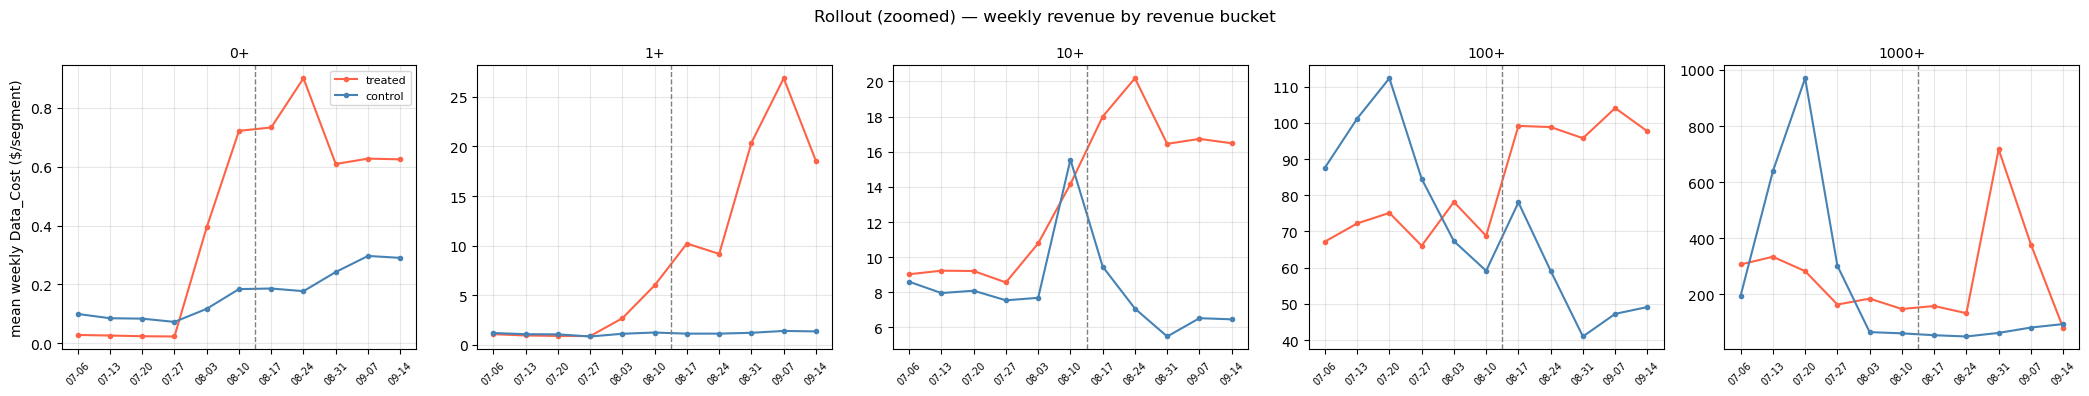

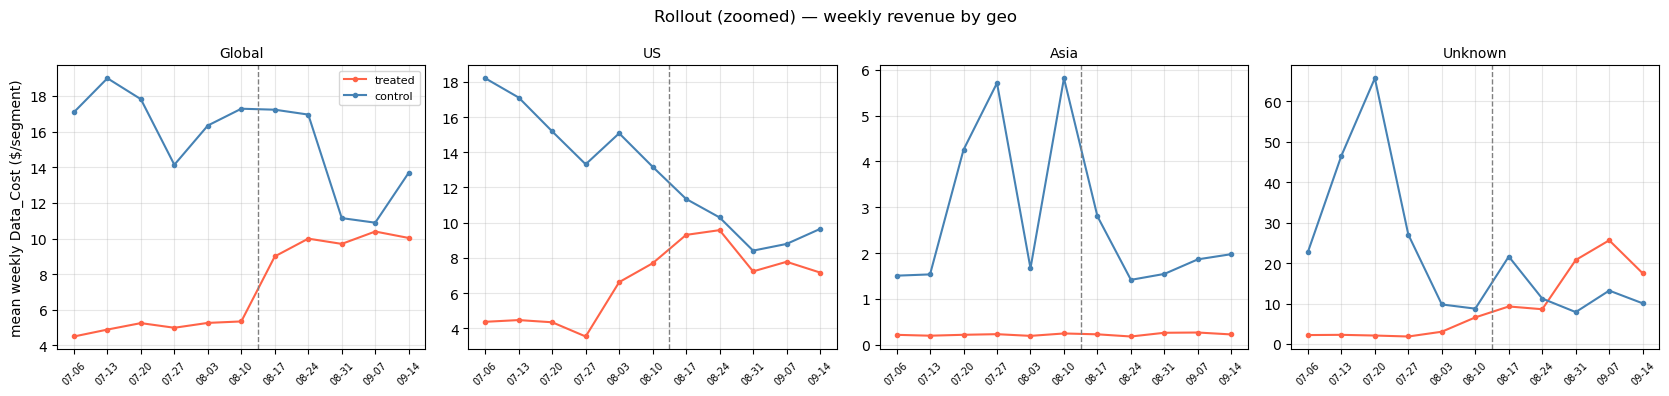

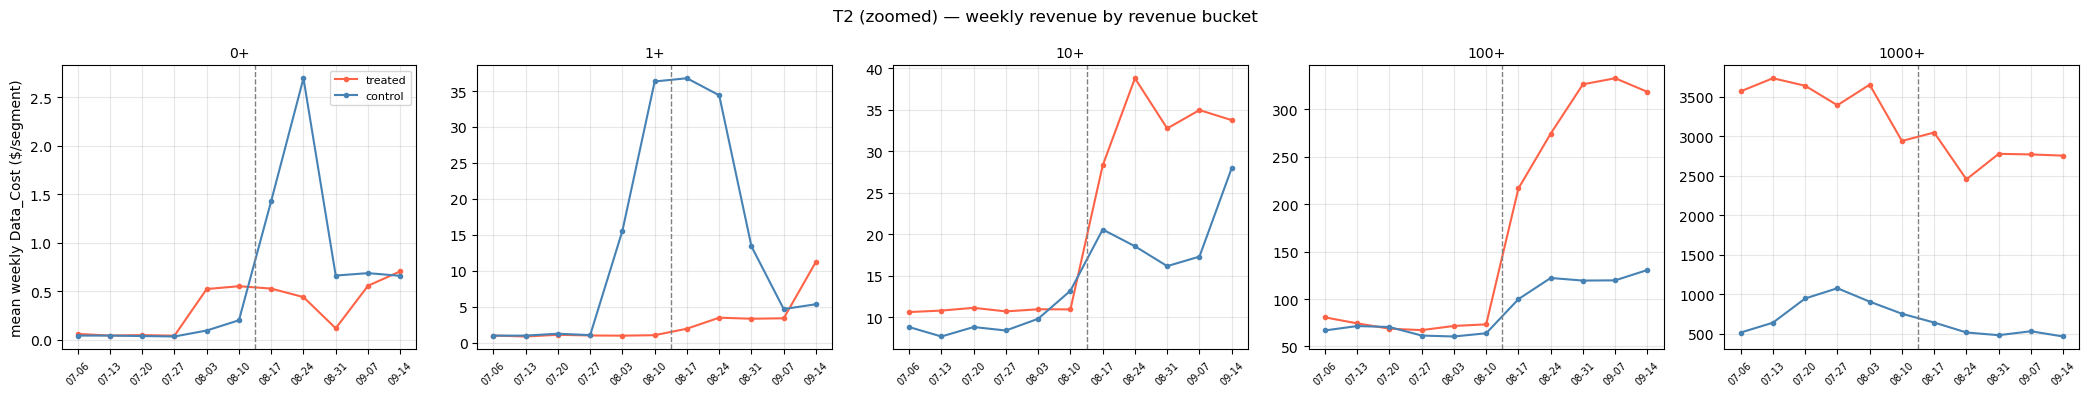

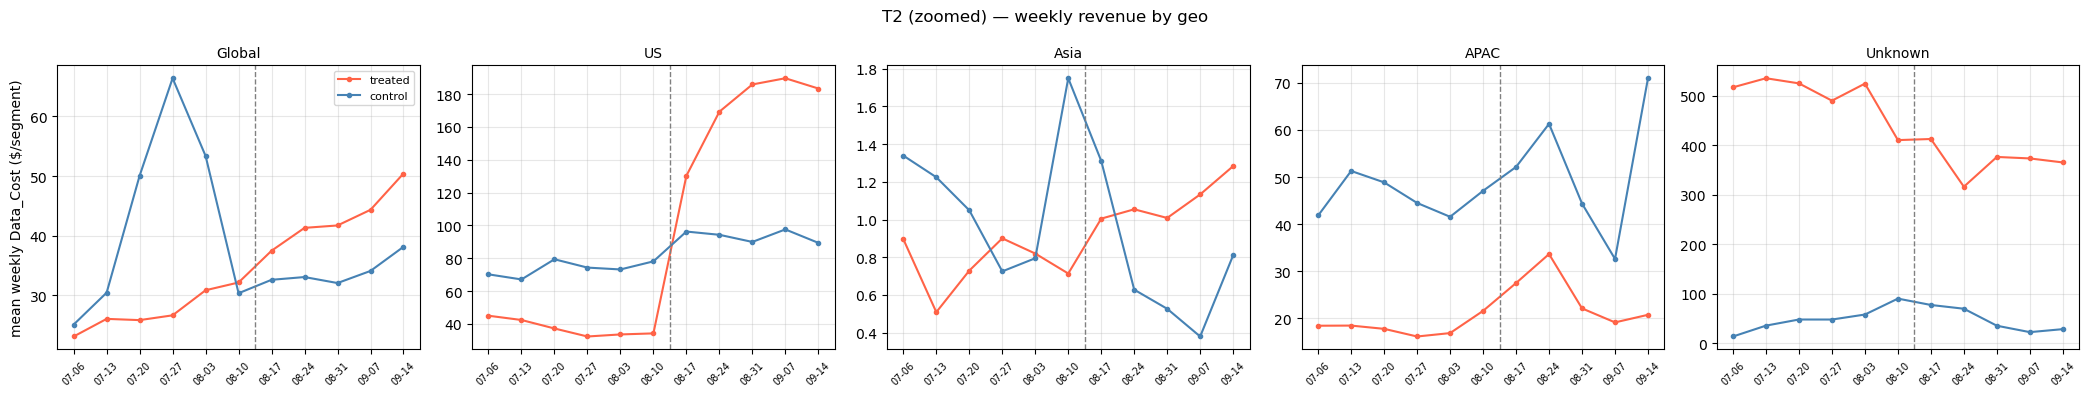

In [24]:
_zoom_roll = panel_roll[panel_roll['Week_Start_Date'] > test_df_start]
_zoom_t2 = panel_t2[panel_t2['Week_Start_Date'] > test_df_start]

plot_weekly_by(_zoom_roll, 'bucket', BUCKET_ORDER, 'Rollout (zoomed) — weekly revenue by revenue bucket')
plot_weekly_by(_zoom_roll, 'geo', ['Global', 'US', 'Asia', 'APAC', 'Unknown'], 'Rollout (zoomed) — weekly revenue by geo')
plot_weekly_by(_zoom_t2, 'bucket', BUCKET_ORDER, 'T2 (zoomed) — weekly revenue by revenue bucket')
plot_weekly_by(_zoom_t2, 'geo', ['Global', 'US', 'Asia', 'APAC', 'Unknown'], 'T2 (zoomed) — weekly revenue by geo')

### Reconciliation check: total sharethis weekly revenue

Total revenue across every sharethis segment and every state (not just the rollout
population) -- for cross-checking against independent reporting before trusting the
rollout-specific numbers below.

**Resolved**: this total runs ~$47-58k/week, well under an independently-reported
~$130k/week figure for sharethis. Confirmed why: every file this notebook touches
(`*-AllOnly.csv`, `RankedByRevenueJuly.csv`, the pricing assignment files) is scoped to
`Full_Path` NOT LIKE '%Custom%' -- roughly a 1:1 match between the weekly panel's 3,589
segments and the pricing candidate universe's 3,588 confirms this isn't a partial/buggy
pull, it's the intended scope. `Custom` segments are reportedly MORE than half of
sharethis's total TTD revenue and are entirely absent from every dataset used here.

**What this means for every number in this notebook**: T1, T2, and the rollout were
only ever run against the non-Custom taxonomy -- the *minority* of sharethis's TTD
revenue. The DiD comparisons themselves (treated vs. control within this scope) are
still valid, but any dollar total below is a total for this scope only, not "the
business." Don't extrapolate a $/week figure here to overall sharethis TTD revenue
without accounting for the untouched Custom segments.

In [25]:
_weekly_totals = dat.groupby('Week_Start_Date')['Data_Cost'].sum().sort_index()
print("Total sharethis weekly revenue, all segments/states, most recent weeks:")
for wk, v in _weekly_totals.tail(10).items():
    print(f"  {str(wk)[:10]}   {v:>12,.0f}")

_pre_mask = (dat['Week_Start_Date'] > test_df_start) & (dat['Week_Start_Date'] <= last_pre_week)
total_sharethis_weekly = dat[_pre_mask].groupby('Week_Start_Date')['Data_Cost'].sum().mean()
print(f"\nAverage over the 6-week pre-period (7/06-8/10) used throughout this notebook: {total_sharethis_weekly:,.0f}/week")

Total sharethis weekly revenue, all segments/states, most recent weeks:
  2026-07-13         46,669
  2026-07-20         48,107
  2026-07-27         44,334
  2026-08-03         49,129
  2026-08-10         48,160
  2026-08-17         57,195
  2026-08-24         54,505
  2026-08-31         58,619
  2026-09-07         62,150
  2026-09-14         62,689

Average over the 6-week pre-period (7/06-8/10) used throughout this notebook: 46,729/week


## Net dollar impact of the rollout — weekly and total

Uses the untrimmed `sum`/`mean` of `did` (not `trim_mean`) — for an actual dollar
total you want every real dollar counted, including whatever a few large segments
contributed; trimming is for judging a *typical* segment's effect, not for adding up
the population's revenue. `did`/`chg` are already weekly rates (post-period average
weekly `Data_Cost` minus pre-period average), so summing across segments gives a
weekly $ aggregate; multiplying by `t_post` (the number of observed post weeks)
gives the cumulative $ impact over the period actually observed so far — not a
forward-looking projection.

Also reported: each bucket's share of the total, and the top-10-segments' share, to
show how concentrated the dollar total is (the mean vs. trim_mean gap earlier already
signaled this would be lopsided).

In [26]:
def dollar_summary(df, val_col, label):
    treated = df[df['delta'] != 0].copy()
    control = df[df['delta'] == 0].copy()
    n = len(treated)
    t_post_vals = treated['t_post'].dropna().unique()
    t_post = int(t_post_vals[0]) if len(t_post_vals) == 1 else None
    weekly_total = treated[val_col].sum()
    total_to_date = weekly_total * t_post if t_post else float('nan')

    # Baseline: pre-period average weekly Data_Cost, summed across the same treated
    # population -- the revenue base the $ impact above should be read against.
    baseline_weekly = treated['Data_Cost_pre'].sum() if 'Data_Cost_pre' in treated.columns else float('nan')
    baseline_to_date = baseline_weekly * t_post if t_post else float('nan')
    pct_lift = weekly_total / baseline_weekly * 100 if baseline_weekly else float('nan')

    print(f"--- {label} ---")
    print(f"n treated = {n} | t_post = {t_post if t_post else 'INCONSISTENT ' + str(list(t_post_vals))}")
    print(f"baseline (pre-period) revenue: {baseline_weekly:,.0f}/week  |  {baseline_to_date:,.0f} over {t_post} weeks")
    print(f"  ({baseline_weekly/total_sharethis_weekly*100:.1f}% of total sharethis weekly revenue of {total_sharethis_weekly:,.0f}/week)")
    print(f"$ impact (sum of {val_col} across treated segments): {weekly_total:,.0f}/week  |  {total_to_date:,.0f} over {t_post} weeks")
    print(f"=> {pct_lift:+.2f}% of baseline weekly revenue")

    if 'Data_Cost_pre' in control.columns and len(control) > 0:
        ctrl_baseline_weekly = control['Data_Cost_pre'].sum()
        print(f"(for reference, the {len(control)} control segments' own pre-period baseline: {ctrl_baseline_weekly:,.0f}/week)")

    if 'bucket' in treated.columns:
        by_bucket = treated.groupby('bucket')[val_col].sum().reindex(BUCKET_ORDER).dropna()
        print("\nshare of weekly total by bucket:")
        for b, v in by_bucket.items():
            print(f"  {b:6s}  {v:>12,.0f}/wk   ({v/weekly_total*100:5.1f}% of total)")

    top10 = treated.nlargest(10, val_col)[val_col].sum() if weekly_total != 0 else 0
    print(f"\ntop 10 segments (of {n}) account for {top10/weekly_total*100:.1f}% of the weekly total\n")

dollar_summary(did_roll_grp, 'did', 'Method 1: group-matched DiD')
dollar_summary(did_roll_bkt, 'did', 'Method 2: bucket-matched DiD')
dollar_summary(treated_only, 'chg', 'Method 3: pre/post trend only')

--- Method 1: group-matched DiD ---
n treated = 267 | t_post = 5
baseline (pre-period) revenue: 1,942/week  |  9,711 over 5 weeks
  (4.2% of total sharethis weekly revenue of 46,729/week)
$ impact (sum of did across treated segments): 3,654/week  |  18,271 over 5 weeks
=> +188.15% of baseline weekly revenue
(for reference, the 148 control segments' own pre-period baseline: 2,154/week)

share of weekly total by bucket:
  0+               348/wk   (  9.5% of total)
  1+               991/wk   ( 27.1% of total)
  10+            1,677/wk   ( 45.9% of total)
  100+             639/wk   ( 17.5% of total)

top 10 segments (of 267) account for 76.0% of the weekly total

--- Method 2: bucket-matched DiD ---
n treated = 2709 | t_post = 5
baseline (pre-period) revenue: 7,856/week  |  39,281 over 5 weeks
  (16.8% of total sharethis weekly revenue of 46,729/week)
$ impact (sum of did across treated segments): 12,085/week  |  60,425 over 5 weeks
=> +153.83% of baseline weekly revenue
(for reference,

### Which segments drove the Method 2 dollar impact?

The dollar total is a sum of per-segment `did` values, so a few large segments can
dominate it. This section shows how concentrated it is, who the top contributors are
(with their weekly revenue, so the timing of each jump is visible against the 8/17
change), and flags two patterns that make a segment's `did` a poor read on the price cut:

- **Pre-window ramp**: revenue jumped during the last two pre-weeks (>10x the earlier
  pre-weeks' median, and >$50). The pre-period mean then understates the level the
  segment was already at, so `did` credits the treatment with a jump that began before it.
- **Thin control**: fewer than 3 control segments in the segment's (geo, bucket) cell,
  so its `control_chg_mean` is one or two segments' noise.

Flags are descriptive -- they do not remove anything from the estimates above.

In [27]:
_t = did_roll_bkt[did_roll_bkt['delta'] != 0].copy()
_tot = _t['did'].sum()

# weekly revenue per segment, pre-window + post-window
_weeks = sorted(dat['Week_Start_Date'].unique())
_pre_w = [w for w in _weeks if test_df_start < w <= last_pre_week]
_post_w = [w for w in _weeks if w > last_pre_week]
_wk = (dat.pivot_table(index='Full_Path', columns='Week_Start_Date', values='Data_Cost', aggfunc='sum')
          .reindex(columns=_pre_w + _post_w).fillna(0.0))

# flags
_early = _wk[_pre_w[:-2]].median(axis=1)
_late = _wk[_pre_w[-2:]].max(axis=1)
_t['ramp_in_pre'] = _t['Full_Path'].map((_late > 10 * _early.clip(lower=1)) & (_late > 50)).fillna(False)
_nctrl = did_roll_bkt[did_roll_bkt['delta'] == 0].groupby('bucket_geo').size()
_t['n_ctrl'] = _t['bucket_geo'].map(_nctrl).fillna(0).astype(int)
_t['thin_ctrl'] = _t['n_ctrl'] < 3
_t['pre_last2'] = _t['Full_Path'].map(_wk[_pre_w[-2:]].mean(axis=1))
_t['post_mean'] = _t['Full_Path'].map(_wk[_post_w].mean(axis=1))
_t['post_vs_last2'] = _t['post_mean'] / _t['pre_last2'].clip(lower=0.01)

_t = _t.sort_values('did', ascending=False).reset_index(drop=True)
_t['share'] = _t['did'] / _tot
_t['cum_share'] = _t['share'].cumsum()

print(f"Method 2 treated segments: {len(_t)} | total did: ${_tot:,.0f}/wk")
print(f"sum of positive did: ${_t.loc[_t.did > 0, 'did'].sum():,.0f} | sum of negative did: ${_t.loc[_t.did < 0, 'did'].sum():,.0f}\n")

print("Concentration:")
_conc = pd.DataFrame({'top_k': [1, 5, 10, 20, 50, 100, 250]})
_conc['$/wk'] = [_t['did'].head(k).sum() for k in _conc['top_k']]
_conc['share_of_total'] = (_conc['$/wk'] / _tot).map('{:.1%}'.format)
_conc['$/wk'] = _conc['$/wk'].map('${:,.0f}'.format)
print(_conc.to_string(index=False))

print("\nTop 15 contributors:")
_top = _t.head(15).copy()
_top['Full_Path'] = _top['Full_Path'].str[-58:]
print(_top[['Full_Path', 'geo', 'bucket', 'did', 'share', 'cum_share', 'ramp_in_pre', 'n_ctrl', 'post_vs_last2']]
      .round({'did': 0, 'share': 3, 'cum_share': 3, 'post_vs_last2': 2}).to_string(index=False))

Method 2 treated segments: 2709 | total did: $12,085/wk
sum of positive did: $13,342 | sum of negative did: $-1,257

Concentration:
 top_k    $/wk share_of_total
     1  $4,563          37.8%
     5  $6,613          54.7%
    10  $7,953          65.8%
    20  $9,050          74.9%
    50 $10,699          88.5%
   100 $12,043          99.7%
   250 $13,043         107.9%

Top 15 contributors:
                                                 Full_Path     geo bucket    did  share  cum_share  ramp_in_pre  n_ctrl  post_vs_last2
                                         Intent > Shopping Unknown     0+ 4563.0  0.378      0.378         True       4          15.63
S > travel > tourist destinations > mountain & ski resorts      US    10+  622.0  0.051      0.429         True      14           1.03
       US > sports > winter sports > skiing & snowboarding      US    10+  565.0  0.047      0.476         True      15           1.05
              Global > Validated Demographic > Age > 45-54  Global

In [28]:
# weekly revenue of the top 15 (pre-weeks, then post-weeks from the 8/17 change onward)
_cols = [w[5:10] for w in _pre_w + _post_w]  # 'MM-DD'
_series = _wk.loc[_t['Full_Path'].head(15)].copy()
_series.columns = _cols
_series.index = [p[-46:] for p in _series.index]
print(f"weekly Data_Cost ($); first {len(_pre_w)} columns are pre-period, remaining {len(_post_w)} are post (8/17 on):")
print(_series.round(0).astype(int).to_string())

weekly Data_Cost ($); first 6 columns are pre-period, remaining 5 are post (8/17 on):
                                                07-06  07-13  07-20  07-27  08-03  08-10  08-17  08-24  08-31  09-07  09-14
Intent > Shopping                                   1      1      1      1      1    596   1906   1298   6319   8883   4920
 tourist destinations > mountain & ski resorts      0      0      0      0    674   1117   1189   1415    761    634    603
sports > winter sports > skiing & snowboarding      2      0      0      0    530   1058   1132   1214    705    564    536
Global > Validated Demographic > Age > 45-54       20     21     31     42     58     78    484    669    538    478    472
ocial Activity > Seasonal > Summer > Travelers    307    334    283    164    185    148    159    133    717    378     80
dated Demographic > Gender and Age > Males 65+    180    210    216    172    178    225    466    635    531    563    479
ted Demographic > Gender and Age > Males 25-34

(groups are mutually exclusive, in the order listed)
                                   group  segments   $/wk share
               pre-window ramp (flagged)         9 $5,993 49.6%
 thin control, <3 ctrl in cell (flagged)         1   $360  3.0%
Validated Demographic (age/gender) paths        68 $3,014 24.9%
                         everything else      2631 $2,718 22.5%

Validated Demographic paths by geo (excluding flagged):
        count     sum
geo                  
Asia       26    48.0
Global     21  2047.0
US         21   919.0

Total excluding flagged segments (descriptive only): $5,732/wk vs $12,085/wk


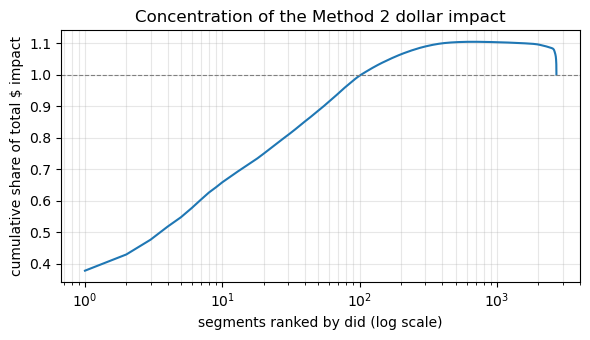

In [29]:
# What the flags and one recognizable cluster account for
_vd = _t['Full_Path'].str.contains('Validated Demographic', regex=False)
_groups = [
    ('pre-window ramp (flagged)', _t['ramp_in_pre']),
    ('thin control, <3 ctrl in cell (flagged)', _t['thin_ctrl'] & ~_t['ramp_in_pre']),
    ('Validated Demographic (age/gender) paths', _vd & ~_t['ramp_in_pre'] & ~_t['thin_ctrl']),
]
_rows = []
_used = pd.Series(False, index=_t.index)
for name, mask in _groups:
    _rows.append({'group': name, 'segments': int(mask.sum()), '$/wk': _t.loc[mask, 'did'].sum(),
                  'share': _t.loc[mask, 'did'].sum() / _tot})
    _used |= mask
_rows.append({'group': 'everything else', 'segments': int((~_used).sum()),
              '$/wk': _t.loc[~_used, 'did'].sum(), 'share': _t.loc[~_used, 'did'].sum() / _tot})
_g = pd.DataFrame(_rows)
_g['$/wk'] = _g['$/wk'].map('${:,.0f}'.format)
_g['share'] = _g['share'].map('{:.1%}'.format)
print("(groups are mutually exclusive, in the order listed)")
print(_g.to_string(index=False))

print("\nValidated Demographic paths by geo (excluding flagged):")
_vdg = _t[_vd & ~_t['ramp_in_pre'] & ~_t['thin_ctrl']].groupby('geo')['did'].agg(['count', 'sum']).round(0)
print(_vdg.to_string())

print(f"\nTotal excluding flagged segments (descriptive only): "
      f"${_t.loc[~(_t['ramp_in_pre'] | _t['thin_ctrl']), 'did'].sum():,.0f}/wk vs ${_tot:,.0f}/wk")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(np.arange(1, len(_t) + 1), _t['cum_share'].values)
ax.set_xscale('log')
ax.axhline(1, color='gray', lw=0.8, ls='--')
ax.set_xlabel('segments ranked by did (log scale)')
ax.set_ylabel('cumulative share of total $ impact')
ax.set_title('Concentration of the Method 2 dollar impact')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

### Scaling Method 1 to the full population: bucket-weighted ATE

Method 1 only covers segments whose match-group retained a surviving control --
confirmed this coverage is NOT uniform across buckets (7.3% of the 0+ tier vs 25% of
1000+), so its raw total undercounts almost entirely by missing low-tier segments, not
because the treatment doesn't work there. Same fix as `TTD3_Pricing.ipynb`'s own
"Route 1: bucket-weighted ATT" -- take Method 1's per-bucket ATT (its own tightest,
most-trusted control comparison) and reweight by each bucket's share of the *full*
2,709-segment population (from Method 2/3's complete coverage), instead of Method 1's
own skewed sample.

In [30]:
full_bucket_n = did_roll_bkt[did_roll_bkt['delta'] != 0].groupby('bucket').size().reindex(BUCKET_ORDER)

def _bucket_att(v):
    trim = float(__trim_mean(v, 0.1)) if len(v) >= 3 else float(v.mean())
    return pd.Series({'mean': v.mean(), 'trim_mean': trim, 'n_method1': len(v)})

m1_treated = did_roll_grp[did_roll_grp['delta'] != 0]
att_by_bucket = m1_treated.groupby('bucket')['did'].apply(_bucket_att).unstack().reindex(BUCKET_ORDER)
att_by_bucket['n_full_pop'] = full_bucket_n
att_by_bucket['coverage_%'] = (att_by_bucket['n_method1'] / att_by_bucket['n_full_pop'] * 100).round(1)

print("Method 1's per-bucket ATT vs. full population bucket size:")
print(att_by_bucket.to_string())

valid = att_by_bucket.dropna(subset=['mean']).index
uncovered_n = full_bucket_n.drop(valid, errors='ignore').fillna(0).sum()

ate_weekly_mean = (full_bucket_n.loc[valid] * att_by_bucket.loc[valid, 'mean']).sum()
ate_weekly_trim = (full_bucket_n.loc[valid] * att_by_bucket.loc[valid, 'trim_mean']).sum()

_t_post_ate = int(m1_treated['t_post'].mode().iloc[0])
print(f"\nATE (Method 1's per-bucket ATT x full-population bucket sizes):")
print(f"  using mean ATT:      ${ate_weekly_mean:,.0f}/week   (${ate_weekly_mean*_t_post_ate:,.0f} over {_t_post_ate} weeks)")
print(f"  using trim_mean ATT: ${ate_weekly_trim:,.0f}/week   (${ate_weekly_trim*_t_post_ate:,.0f} over {_t_post_ate} weeks)")
if uncovered_n > 0:
    print(f"  ({uncovered_n:.0f} segments in buckets Method 1 has no ATT for -- e.g. 1000+, lost to group-bucket "
          f"reconciliation -- excluded from this extrapolation, not assumed to be zero)")

Method 1's per-bucket ATT vs. full population bucket size:


             mean  trim_mean  n_method1  n_full_pop  coverage_%
bucket                                                         
0+       2.349959   0.107492      148.0      2078.0         7.1
1+      16.789040   2.035905       59.0       360.0        16.4
10+     34.929007  18.058875       48.0       231.0        20.8
100+    53.266750  22.943833       12.0        40.0        30.0
1000+         NaN        NaN        NaN         NaN         NaN

ATE (Method 1's per-bucket ATT x full-population bucket sizes):
  using mean ATT:      $21,127/week   ($105,633 over 5 weeks)
  using trim_mean ATT: $6,046/week   ($30,228 over 5 weeks)


### Why ATE differs so much from ATT (and which to trust)

**ATT ($3,654/week) is not "the rollout's effect" -- it's the effect measured on a
small, non-random slice of it.** Method 1 only keeps segments whose 3-slot group
happened to retain an untreated member -- 267 of 2,709 (coverage 7-30%, worst at the
bottom bucket). That's not a random sample: 645 groups were fully swept 3:0 and 248
were 2:0, so the majority of the rollout has no surviving control at all under Method
1's strict rule. "ATT" here means "effect on the ~10% of segments lucky enough to have
kept a group-mate untouched," not "effect on the rollout."

**ATE takes that small sample's per-segment average and multiplies it by the FULL
bucket population** -- e.g. the 0+ bucket's mean ATT (2.35, from just 148 segments)
gets multiplied by the full population's 2,078 segments in that bucket, a 14x
scale-up. Two things inflate this: (1) a mean estimated from as few as 12-59 segments,
scaled up 3-14x, amplifies any noise or outlier in that tiny sample proportionally; (2)
whether a group happened to keep a surviving control isn't guaranteed independent of
the outcome -- the 267 "lucky" segments aren't necessarily typical of the 2,442 that
were fully swept. This is also why mean-ATE ($21,127) and trim_mean-ATE ($6,046) differ
3.5x: a couple of large-revenue outliers in Method 1's small per-bucket samples get
scaled up right along with everything else.

**The fix this is implicitly reaching for already exists -- it's Method 2.** Method
2/3 directly measure 2,709 of the ~2,857 rollout segments (near-exhaustive, no
extrapolation needed), giving **$12,085/week** with no scale-up assumption at all --
this sits between the two ATE variants and is the number to actually trust. The ATE
step made sense for the *original* T1 experiment (a genuinely small designed test that
needed extrapolating to an untested population), but is largely redundant for the
rollout, where near-full-population coverage was already achieved directly. Treat
Method 1 + this ATE extrapolation as a sensitivity check on Method 2, not the primary
number.

### The May cohort — two checks

The May cohort (already at `-0.05` since the original T1 launch, not the current
rollout) is checked two ways:

1. **True pre/post, replicating the original T1 experiment** — pre = before the 5/26
   launch (`test_df_start_may`/`last_pre_week_may`, same window `TTD3_Pricing.ipynb`
   used), post = every week since, through the current 8/17 data. This asks "has the
   original May effect held up," using the same segments TTD3_Pricing analyzed but with
   ~3 more months of post-period data now available.
2. **Same window as the Aug cohort** (7/06-8/10 pre vs 8/17 post) — nothing happened to
   this cohort at the 8/17 round, so this should show **no new change**. It's a placebo
   check on the current analysis window, not a re-test of the original effect.

In [31]:
may_rows = pd.concat([may_cohort, clean_ctrl], ignore_index=True)
may_rows['delta'] = np.where(may_rows['state'] == 'T1 -0.05', -0.05, 0.0)
may_rows = assign_bucket(may_rows)

# --- Part 1: true pre/post (original T1 window, extended through 8/17) ---
panel_may_orig = build_zero_filled_panel(dat, may_rows, last_pre_week=last_pre_week_may)
did_may_orig, _, _ = compute_did(panel_may_orig, test_df_start_may, match_col='group')
print(f"Part 1 -- true pre/post (pre: before 5/26, post: 5/25 through 8/17), n={len(did_may_orig)}:")
print(desc_stats(did_may_orig, 'did').to_string(index=False))

# --- Part 2: same window as the Aug cohort (placebo check) ---
panel_may_recent = build_zero_filled_panel(dat, may_rows, last_pre_week=last_pre_week)
did_may_recent, _, _ = compute_did(panel_may_recent, test_df_start, match_col='group')
print(f"\nPart 2 -- placebo check, same window as Aug cohort (pre: 7/06-8/10, post: 8/17), n={len(did_may_recent)}:")
print(desc_stats(did_may_recent, 'did').to_string(index=False))

Part 1 -- true pre/post (pre: before 5/26, post: 5/25 through 8/17), n=173:
 delta   n t_pre t_post   mean  trim_mean    std  cdf0      p5   q25  median   q75   p95    p_t  p_trim  p_wilcox
 -0.05  25     6     17 -3.878      0.051 19.578 0.400 -20.659 -2.45    0.14 2.479 8.337 0.3415  0.9608    0.7915
  0.00 148     6     17 -0.000      0.000  7.403 0.993   0.000  0.00    0.00 0.000 0.000 1.0000     NaN    0.6547

Part 2 -- placebo check, same window as Aug cohort (pre: 7/06-8/10, post: 8/17), n=173:
 delta   n t_pre t_post   mean  trim_mean    std  cdf0      p5    q25  median   q75   p95    p_t  p_trim  p_wilcox
 -0.05  25     6      5 -0.211     -1.065 14.006 0.640 -15.582 -3.162  -0.692 1.306 9.805 0.9417  0.1245    0.2752
  0.00 148     6      5 -0.000      0.000  2.975 0.993   0.000  0.000   0.000 0.000 0.000 1.0000     NaN    0.6547


## Summary & caveats

- **T2**: see the numbers above — control is the full, un-filtered `C2` population.
  Earlier drafts of this analysis wrongly excluded much of `C2` based on an
  intermediate assignment snapshot (2026-07-27) that turned out to have never actually
  gone live (see the confirmation near the top) — those exclusions have been reverted.
- **Rollout**: numbers above are for the **Aug cohort only** (segments whose price
  actually changed at the 8/17 round, via the file's own `delta` column) — this is the
  population that actually answers "what did the Aug rollout do," as opposed to pooling
  in ~270 already-converged May-experiment segments that had no new event to measure at
  8/17.
- **The May cohort, Part 1** (true pre/post, extending the original T1 window through
  8/17) — see its own output above for whether the original May effect has held up.
- **The May cohort, Part 2** (placebo, same window as the Aug cohort) — see its own
  output above for whether it came out flat, as expected for a group nothing happened
  to this round. If it didn't, that's a signal something other than the rollout
  (seasonality, a reporting artifact) may be contributing to the Aug-cohort estimate
  too, and is worth chasing before treating the Aug-cohort number as clean.
- **Why the pre-window is 6 recent weeks, not the full history.** A longer pre-window
  (back to 5/26) is available and valid (confirmed nothing changed until 8/17), but adds
  more data than needed — 6 recent weeks is a sufficient, simpler baseline for T2 and
  the Aug cohort. The May cohort's Part-1 check is the one place the longer history
  earns its keep, since 7/06-8/10 can't serve as *its* baseline (it's already
  post-treatment for that group).
- **Now a two-week post-period** (8/17 and 8/24) instead of one — check the t_post
  column above reads '2' everywhere it should; still early, but stronger than the
  first pass.
- Rollout eligibility was gated on **May revenue ≤ $1000**, not randomized — the bucket
  breakdowns above are the main defense against attributing a revenue-bucket-composition
  difference to the price change itself.
- **Scope: non-Custom `Full_Path` only.** Every dataset used in this notebook excludes
  `Full_Path LIKE '%Custom%'` segments, which reportedly account for more than half of
  sharethis's total TTD revenue. T1/T2/the rollout were never run against Custom
  segments at all — the DiD comparisons are valid within this scope, but the dollar
  totals above are not a complete picture of sharethis's overall TTD revenue.